In [1]:
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
import random
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from sklearn import svm
from scipy.linalg import solve
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
seed = 1
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)


In [3]:
#create pandas dataframe from data

In [4]:
df_sessions_m1_phase1 = {}

monkey = 1
directory = '/home/dvoina/myproj1/pooya_data/M' + str(monkey) + '_Phase3_Lf_gratings/'
files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
files_split = [f.split('_') for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

In [5]:
new_files = []
for i, f in enumerate(files_split):
    new_files.append([])
    new_files[i].append(int(f[0][1:]))
    new_files[i].append(int(f[1][1:]))
new_files = np.array(new_files)

In [6]:
n_sessions = len(np.unique(np.array(new_files[:, 1])))
n_sessions

5

In [7]:
list_of_stim = ["circ", "circ", "rad", "rad"]*7
list_of_snr = [1.0]*4 + [0.8]*4 + [0.65]*4 + [0.5]*4 + [0.35]*4 + [0.2]*4 + [0.05]*4
list_of_pos = ["R", "L"] * 14

In [8]:
def get_neuron_rows(n, filename):
    mat_contents = sio.loadmat(directory + filename)

    #print("NEURON N", n)
    total_rows = 0
    list_of_stim_ = [1 if list_of_stim[i] == "circ" else 0 for i in range(len(list_of_stim)) ]

    rows = []
    for trial in range(28):

        #print("trial", trial)
        spikes = mat_contents["Spike_mat"][0][trial]["spikes"]
        errors = mat_contents["Spike_mat"][0][trial]["errors"]
        rt = mat_contents["Spike_mat"][0][trial]["saccade_t"]
        
        n_trials = spikes.shape[0]
        #print("n_trials", n_trials)

        for t in range(n_trials):
            
            if errors[t][0] == 0:
                choice = list_of_stim_[trial]
            else:
                choice = 1 - list_of_stim_[trial]
                
            rows.append({
                "neuron_id": n,
                "spike_ts": np.array(spikes[t,:]).flatten(),
                "firing": np.array(spikes[t,:]).flatten()[500:750].sum(), #/(850-500),
                "stim": list_of_stim[trial],
                "snr": list_of_snr[trial],
                "pos": list_of_pos[trial],
                "error": errors[t][0],
                "choice": choice,
                "reaction_time": rt[t][0],
                "trial": total_rows
            })

            total_rows += 1

    #print("total_rows", total_rows)
    return rows

dict_of_neurons = {}
for session in np.unique(new_files[:, 1]):
    ind_s = np.where(new_files[:, 1] == session)[0]
    neurons = new_files[ind_s, 0]
    dict_of_neurons[str(session)] = neurons
    
    #print("neuron number", neurons, len(neurons))
    files_s = [files[i] for i in ind_s]
    #print("session", session, neurons, files_s)

    all_rows = []
    for n, filename in zip(neurons, files_s):
        all_rows.extend(get_neuron_rows(n, filename))
        #print("len all rows", len(all_rows))
        
    df_sessions_m1_phase1[str(session)] = pd.DataFrame(all_rows, columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "pos", "error", "choice", "reaction_time", "trial"])
    

In [9]:
correct_choice = [1 if df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].stim.iloc[i] == "circ" else 0 for i in range(len(df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].stim)) ]
real_choice = df_sessions_m1_phase1["3"][df_sessions_m1_phase1["3"].snr.isin([0.65,0.8,1.0])].choice

(correct_choice - real_choice).sum()/len(correct_choice)

-0.013793103448275862

In [10]:
for session in range(1, n_sessions+1):
    df = df_sessions_m1_phase1[str(session)]
    # pick one neuron to avoid triple-counting
    n0 = df.neuron_id.iloc[0]
    df1 = df[(df.neuron_id == n0)]# & (df.snr.isin([1.0, 0.8, 0.65]))]
    
    circ_trials = df1[df1.stim == 'circ']
    rad_trials  = df1[df1.stim == 'rad']
    
    circ_errors = (circ_trials.error == 6).sum()
    rad_errors  = (rad_trials.error == 6).sum()
    
    print(f"Session {session}: "
          f"circ {len(circ_trials)} trials ({circ_errors} errors), "
          f"rad {len(rad_trials)} trials ({rad_errors} errors)")

Session 1: circ 155 trials (46 errors), rad 147 trials (44 errors)
Session 2: circ 97 trials (18 errors), rad 95 trials (25 errors)
Session 3: circ 130 trials (31 errors), rad 171 trials (36 errors)
Session 4: circ 107 trials (21 errors), rad 147 trials (27 errors)
Session 5: circ 129 trials (31 errors), rad 138 trials (40 errors)


In [11]:
dict_of_neurons

{'1': array([ 1,  6,  3, 10,  8,  4,  5, 11,  2,  9,  7]),
 '2': array([2, 5, 7, 6, 1, 4, 3, 8]),
 '3': array([14,  7, 13,  5,  2, 11,  9, 10,  3,  8,  4,  1, 12,  6]),
 '4': array([4, 3, 6, 1, 7, 2, 5]),
 '5': array([ 1,  6,  3, 10,  8,  4,  5,  2,  9,  7])}

In [12]:
def find_tuned_neurons(df, session, snr_list=[1.0, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]):
    
    neurons = np.unique(df[str(session)].neuron_id.values)
    neurons_tuned_circ = []
    neurons_tuned_rad = []
    neurons_untuned = []
    
    for n in neurons:

        circular_firings = []
        radial_firings = []
        for SNR in snr_list:
            circular = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]
            radial = df_sessions_m1_phase1[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == n)]

            #print(len(circular.firing.values), len(radial.firing.values))
            
            circular_firings += list(circular.firing.values)
            radial_firings += list(radial.firing.values)

        stat, p_value = mannwhitneyu(circular_firings, radial_firings, alternative='two-sided')
        
        """
        if p_value<=0.05:
            if np.array(circular_firings).mean() > np.array(radial_firings).mean():
                neurons_tuned_circ.append(n)
            else:       
                neurons_tuned_rad.append(n)
        else:
            neurons_untuned.append(n)
        """
        stat, p_value1 = mannwhitneyu(circular_firings, radial_firings, alternative='greater')
        stat, p_value2 = mannwhitneyu(radial_firings, circular_firings, alternative='greater')
        stat, p_value = mannwhitneyu(radial_firings, circular_firings, alternative='two-sided')
        #print("p value", p_value, np.array(circular_firings).mean(), np.array(radial_firings).mean())
        print("p_values", p_value1, p_value2)
        
        if p_value1<=0.05:
                neurons_tuned_circ.append(n)
        if p_value2<=0.05:       
                neurons_tuned_rad.append(n)
        if (p_value1 > 0.05) and (p_value2 >0.05):
            neurons_untuned.append(n)
    return neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, 1, snr_list=[1])
tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
neurons_tuned_circ, neurons_tuned_rad, neurons_untuned

p_values 0.0356865212474796 0.9693370220058178
p_values 0.8194973250139506 0.19137153357824854
p_values 0.08036525631644659 0.9249319009188455
p_values 0.004081192547138126 0.9963124043834098
p_values 0.016527693394250816 0.9851650232432355
p_values 0.14586281298789971 0.8620307172984252
p_values 0.9358175883158537 0.06848596274507157
p_values 0.7637170403802822 0.2467033193665613
p_values 0.5732142764855729 0.43998530664923646
p_values 0.05698238001166098 0.9468835943438155
p_values 0.004428733066599844 0.9960530474144412


([1, 4, 5, 11], [], [2, 3, 6, 7, 8, 9, 10])

In [13]:
#Q1:What is the imbalance? in toy model: 80% versus 20%

total_neuron_number = 0
total_number_tuned_circular = 0
total_number_tuned_radial = 0
total_number_untuned = 0

number_tuned_circular = []
number_tuned_radial = []
number_untuned = []

neuron_id_tuned_circular = []
neuron_id_tuned_radial = []
neuron_id_tuned_untuned = []

percentage_of_interest_circ_vs_rad = []
percentage_of_interest_stim_vs_untuned = []

for session in range(1,n_sessions+1):
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])

    print(neurons_tuned_circ)
    print(neurons_tuned_rad)
    print(neurons_untuned)
    total_number_tuned_circular += len(neurons_tuned_circ)
    total_number_tuned_radial += len(neurons_tuned_rad)
    total_number_untuned += len(neurons_untuned)

    number_tuned_circular.append(len(neurons_tuned_circ))
    number_tuned_radial.append(len(neurons_tuned_rad))
    number_untuned.append(len(neurons_untuned))

    neurons_tuned_circ = np.array(neurons_tuned_circ) + total_neuron_number
    neurons_tuned_rad = np.array(neurons_tuned_rad) + total_neuron_number
    neurons_untuned = np.array(neurons_untuned) + total_neuron_number

    neuron_id_tuned_circular += list(neurons_tuned_circ)
    neuron_id_tuned_radial += list(neurons_tuned_rad)
    neuron_id_tuned_untuned += list(neurons_untuned)
    
    total_neuron_number += len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(neurons_untuned)
    
    if len(neurons_tuned_circ) + len(neurons_tuned_rad) != 0:
        percentage_of_interest_circ_vs_rad.append(len(neurons_tuned_circ)/(len(neurons_tuned_circ) + len(neurons_tuned_rad)))
    else:
        percentage_of_interest_circ_vs_rad.append(0)
    percentage_of_interest_stim_vs_untuned.append((len(neurons_tuned_circ) + len(neurons_tuned_rad))/(len(neurons_tuned_circ) + len(neurons_tuned_rad) + len(number_untuned)))
    

session 1
p_values 0.0356865212474796 0.9693370220058178
p_values 0.8194973250139506 0.19137153357824854
p_values 0.08036525631644659 0.9249319009188455
p_values 0.004081192547138126 0.9963124043834098
p_values 0.016527693394250816 0.9851650232432355
p_values 0.14586281298789971 0.8620307172984252
p_values 0.9358175883158537 0.06848596274507157
p_values 0.7637170403802822 0.2467033193665613
p_values 0.5732142764855729 0.43998530664923646
p_values 0.05698238001166098 0.9468835943438155
p_values 0.004428733066599844 0.9960530474144412
[1, 4, 5, 11]
[]
[2, 3, 6, 7, 8, 9, 10]
session 2
p_values 0.10158541904084234 0.908097156296183
p_values 0.003109786729044419 0.9973572695520307
p_values 0.0010744138097616334 0.9990682976870725
p_values 0.009012735073079245 0.9919569151183258
p_values 0.02993886152285302 0.9730123600871105
p_values 0.4916706923258247 0.5249734060093488
p_values 0.0586848899230453 0.9469985363954367
p_values 0.5592303929931736 0.45761598483997923
[2, 3, 4, 5]
[]
[1, 6, 7, 

In [14]:
#neuron_id_tuned_circular_just1 = neuron_id_tuned_circular.copy()
#neuron_id_tuned_radial_just1 = neuron_id_tuned_radial.copy()

print("total neuron number: ", total_neuron_number)
print(neuron_id_tuned_circular, neuron_id_tuned_radial, neuron_id_tuned_untuned)
print(len(neuron_id_tuned_circular), len(neuron_id_tuned_radial), len(neuron_id_tuned_untuned))
#print(neuron_id_tuned_circular_just1, neuron_id_tuned_radial_just1)

total neuron number:  50
[1, 4, 5, 11, 13, 14, 15, 16, 21, 22, 27, 28, 29, 30, 32, 35, 36, 39, 41, 43, 44, 45, 47, 50] [26, 31] [2, 3, 6, 7, 8, 9, 10, 12, 17, 18, 19, 20, 23, 24, 25, 33, 34, 37, 38, 40, 42, 46, 48, 49]
24 2 24


In [15]:
print(total_number_tuned_circular, total_number_tuned_radial, total_number_untuned)
print(total_number_tuned_circular/(total_number_tuned_circular + total_number_tuned_radial))
print((total_number_tuned_circular + total_number_tuned_radial)/(total_number_tuned_circular + total_number_tuned_radial + total_number_untuned))

24 2 24
0.9230769230769231
0.52


Text(0, 0.5, 'percentage tuned')

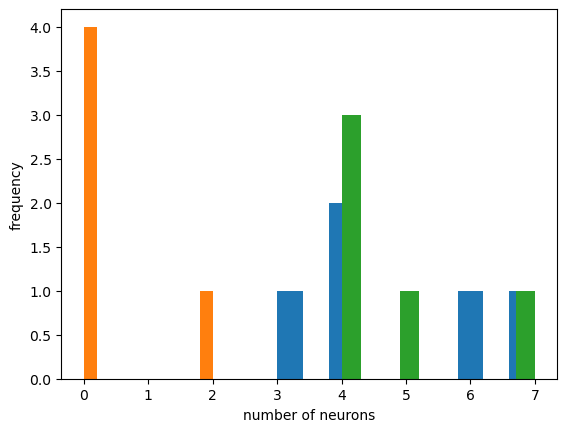

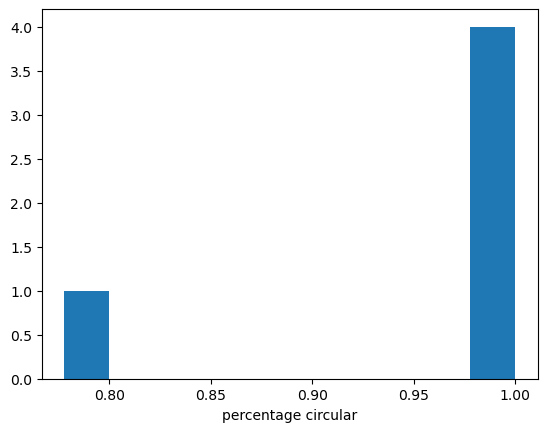

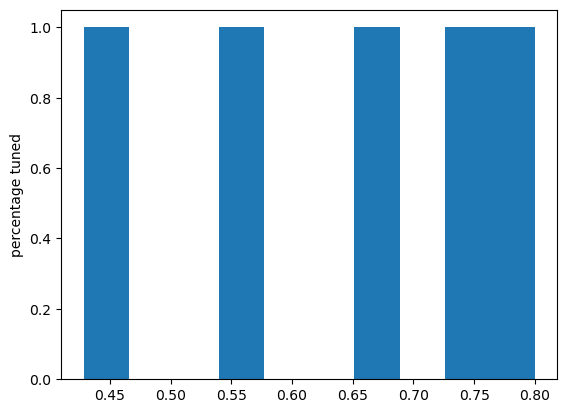

In [16]:
plt.hist(number_tuned_circular)
plt.hist(number_tuned_radial)
plt.hist(number_untuned)
plt.xlabel("number of neurons")
plt.ylabel("frequency")

plt.figure()
plt.hist(percentage_of_interest_circ_vs_rad)
plt.xlabel("percentage circular")

plt.figure()
plt.hist(percentage_of_interest_stim_vs_untuned)
plt.ylabel("percentage tuned")

In [17]:
percentage_of_interest_circ_vs_rad

[1.0, 1.0, 0.7777777777777778, 1.0, 1.0]

In [18]:
#Conclusion: 80% of cells tuned for circular is a good choice but this is for SNR=1.0
# for lower SNR, there are sometimes fewer cells tuned for circular (see e.g., SNR=0.35)

#Possible choice 50+% cells tuned

#Important observation: are "cells tuned for circular" counted at SNR=1.0 (or low noise anyway)??

In [19]:
#create matrix of firing rate for neurons tuned to circular, radial stimuli

In [20]:
def plot(df, session, tunings, SNR):

    [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned] = tunings

    matrix_of_firing_circular = []
    matrix_of_firing_radial = []
    mean_matrix_firing_circular = []
    mean_matrix_firing_radial = []
    for nc in neurons_tuned_circ:
        #df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        df_partial = df[str(session)][(df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_firing_circular += list(df_partial.firing.values)
        mean_matrix_firing_circular.append(np.array(df_partial.firing.values).mean())
        
    for nr in neurons_tuned_rad:
        #df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        df_partial = df[str(session)][(df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_firing_radial += list(df_partial.firing.values)
        mean_matrix_firing_radial.append(np.array(df_partial.firing.values).mean())
        
    """
    try:
        matrix_of_firing_circular = np.stack(matrix_of_firing_circular)
        print("shape1", matrix_of_firing_circular.shape)
    except ValueError:
        print("empty circular (rare)")
    try:
        matrix_of_firing_radial = np.stack(matrix_of_firing_radial)
        print("shape2", matrix_of_firing_radial.shape)
    except ValueError:
        print("empty radial")
    """   

    """
    plt.figure()
    plt.plot(matrix_of_firing_circular.mean(1), "*")
    plt.plot(matrix_of_firing_radial.mean(1), "*")
    plt.xlabel("neuron index")
    plt.ylabel("avg firing")
    """

    return matrix_of_firing_circular, matrix_of_firing_radial, mean_matrix_firing_circular, mean_matrix_firing_radial


M_firing_radial = []
M_firing_circular = []
M_firing_mean_radial = []
M_firing_mean_circular = []
for session in range(1,n_sessions+1):
    
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])
    tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
    print("number of neurons_tuned_rad", len(neurons_tuned_rad))
    print("number of neurons_tuned_circ", len(neurons_tuned_circ))
    
    #print("tunings", tunings)
    matrix_of_firing_circular, matrix_of_firing_radial, mean_matrix_firing_circular, mean_matrix_firing_radial = plot(df_sessions_m1_phase1, session, tunings, 1.0)

    M_firing_circular += matrix_of_firing_circular
    M_firing_radial += matrix_of_firing_radial
    M_firing_mean_circular += mean_matrix_firing_circular
    M_firing_mean_radial += mean_matrix_firing_radial
    
print(len(M_firing_circular), len(M_firing_radial))
print("mean firing rate, circular and radial: ", np.array(M_firing_circular).mean(), np.array(M_firing_radial).mean())
print("mean firing rate, circular and radial v2: ", np.array(M_firing_mean_circular).mean(), np.array(M_firing_mean_radial).mean())

session 1
p_values 0.0356865212474796 0.9693370220058178
p_values 0.8194973250139506 0.19137153357824854
p_values 0.08036525631644659 0.9249319009188455
p_values 0.004081192547138126 0.9963124043834098
p_values 0.016527693394250816 0.9851650232432355
p_values 0.14586281298789971 0.8620307172984252
p_values 0.9358175883158537 0.06848596274507157
p_values 0.7637170403802822 0.2467033193665613
p_values 0.5732142764855729 0.43998530664923646
p_values 0.05698238001166098 0.9468835943438155
p_values 0.004428733066599844 0.9960530474144412
number of neurons_tuned_rad 0
number of neurons_tuned_circ 4
session 2
p_values 0.10158541904084234 0.908097156296183
p_values 0.003109786729044419 0.9973572695520307
p_values 0.0010744138097616334 0.9990682976870725
p_values 0.009012735073079245 0.9919569151183258
p_values 0.02993886152285302 0.9730123600871105
p_values 0.4916706923258247 0.5249734060093488
p_values 0.0586848899230453 0.9469985363954367
p_values 0.5592303929931736 0.45761598483997923
numbe

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([1.93617021, 2.18723404, 2.43829787, 2.6893617 , 2.94042553,
        3.19148936, 3.44255319, 3.69361702, 3.94468085, 4.19574468,
        4.44680851]),
 <BarContainer object of 10 artists>)

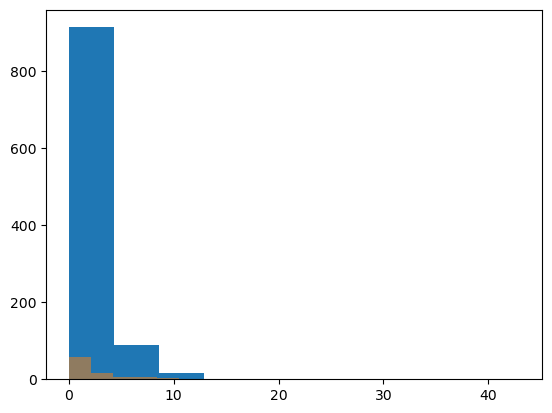

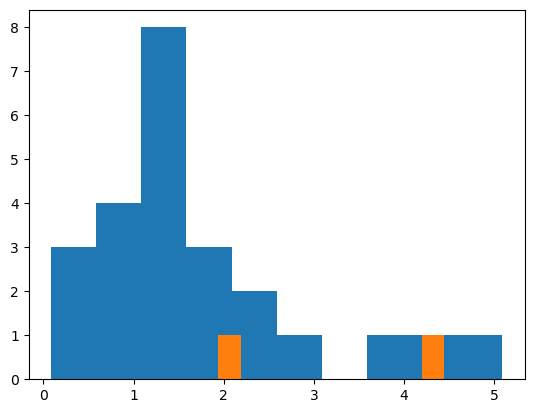

In [21]:
_ = plt.hist(np.array(M_firing_circular))
_ = plt.hist(np.array(M_firing_radial), alpha=0.5)

plt.figure()
plt.hist(M_firing_mean_circular)
plt.hist(M_firing_mean_radial)

In [22]:
#Q2: what is the level of firing rate of: (a) neurons tuned to circ firing for circ; (b) neurons tuned to circ firing for rad; 
# (c) neurons tuned to rad firing for circ; (d) neurons tuned to rad firing for rad.

In [23]:
def plot(df, session, tunings, SNR):

    [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned] = tunings

    matrix_of_tuned_circ_to_stim_circ = []
    matrix_of_tuned_circ_to_stim_rad = []
    mean_matrix_tuned_circ_to_stim_circ = []
    mean_matrix_tuned_circ_to_stim_rad = []
    matrix_of_tuned_rad_to_stim_rad = []
    matrix_of_tuned_rad_to_stim_circ = []
    mean_matrix_tuned_rad_to_stim_circ = []
    mean_matrix_tuned_rad_to_stim_rad = []
    for nc in neurons_tuned_circ:
        df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_tuned_circ_to_stim_circ += list(df_partial.firing.values)
        mean_matrix_tuned_circ_to_stim_circ.append(np.array(df_partial.firing.values).mean())

        df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nc)]
        matrix_of_tuned_circ_to_stim_rad += list(df_partial.firing.values)
        mean_matrix_tuned_circ_to_stim_rad.append(np.array(df_partial.firing.values).mean())
        
    for nr in neurons_tuned_rad:
        df_partial = df[str(session)][(df[str(session)].stim == 'rad') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_tuned_rad_to_stim_rad += list(df_partial.firing.values)
        mean_matrix_tuned_rad_to_stim_rad.append(np.array(df_partial.firing.values).mean())
        
        df_partial = df[str(session)][(df[str(session)].stim == 'circ') & (df[str(session)].snr == SNR) & (df[str(session)].neuron_id == nr)]
        matrix_of_tuned_rad_to_stim_circ += list(df_partial.firing.values)
        mean_matrix_tuned_rad_to_stim_circ.append(np.array(df_partial.firing.values).mean())
        
    """
    try:
        matrix_of_firing_circular = np.stack(matrix_of_firing_circular)
        print("shape1", matrix_of_firing_circular.shape)
    except ValueError:
        print("empty circular (rare)")
    try:
        matrix_of_firing_radial = np.stack(matrix_of_firing_radial)
        print("shape2", matrix_of_firing_radial.shape)
    except ValueError:
        print("empty radial")
    """   

    """
    plt.figure()
    plt.plot(matrix_of_firing_circular.mean(1), "*")
    plt.plot(matrix_of_firing_radial.mean(1), "*")
    plt.xlabel("neuron index")
    plt.ylabel("avg firing")
    """

    return matrix_of_tuned_circ_to_stim_circ, matrix_of_tuned_circ_to_stim_rad, matrix_of_tuned_rad_to_stim_rad, matrix_of_tuned_rad_to_stim_circ, mean_matrix_tuned_circ_to_stim_circ, mean_matrix_tuned_circ_to_stim_rad, mean_matrix_tuned_rad_to_stim_rad, mean_matrix_tuned_rad_to_stim_circ 
    

tuned_circ_to_stim_circ = []
tuned_circ_to_stim_rad = []
tuned_rad_to_stim_rad = []
tuned_rad_to_stim_circ = []
mean_tuned_circ_to_stim_circ = []
mean_tuned_circ_to_stim_rad = []
mean_tuned_rad_to_stim_rad = []
mean_tuned_rad_to_stim_circ = []
for session in range(1,n_sessions+1):
    
    print("session", session)
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session, snr_list=[1.0])
    tunings = [neurons_tuned_circ, neurons_tuned_rad, neurons_untuned]
    #print("tunings", tunings)
    results = plot(df_sessions_m1_phase1, session, tunings, 1.0)

    tuned_circ_to_stim_circ += results[0]
    tuned_circ_to_stim_rad += results[1]
    tuned_rad_to_stim_rad += results[2]
    tuned_rad_to_stim_circ += results[3]
    mean_tuned_circ_to_stim_circ += results[4]
    mean_tuned_circ_to_stim_rad += results[5]
    mean_tuned_rad_to_stim_rad += results[6]
    mean_tuned_rad_to_stim_circ += results[7]

session 1
p_values 0.0356865212474796 0.9693370220058178
p_values 0.8194973250139506 0.19137153357824854
p_values 0.08036525631644659 0.9249319009188455
p_values 0.004081192547138126 0.9963124043834098
p_values 0.016527693394250816 0.9851650232432355
p_values 0.14586281298789971 0.8620307172984252
p_values 0.9358175883158537 0.06848596274507157
p_values 0.7637170403802822 0.2467033193665613
p_values 0.5732142764855729 0.43998530664923646
p_values 0.05698238001166098 0.9468835943438155
p_values 0.004428733066599844 0.9960530474144412
session 2
p_values 0.10158541904084234 0.908097156296183
p_values 0.003109786729044419 0.9973572695520307
p_values 0.0010744138097616334 0.9990682976870725
p_values 0.009012735073079245 0.9919569151183258
p_values 0.02993886152285302 0.9730123600871105
p_values 0.4916706923258247 0.5249734060093488
p_values 0.0586848899230453 0.9469985363954367
p_values 0.5592303929931736 0.45761598483997923
session 3
p_values 0.1283471244594288 0.8764428341539103
p_values 

2.568156108597285 1.0059901909947282 4.125 1.8157894736842104
2.6587982832618025 1.021543985637343 4.125 1.8157894736842106


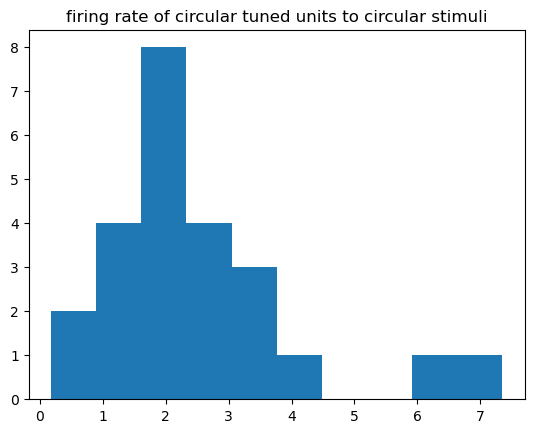

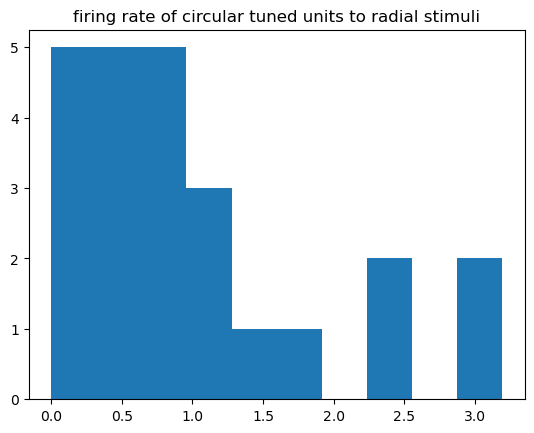

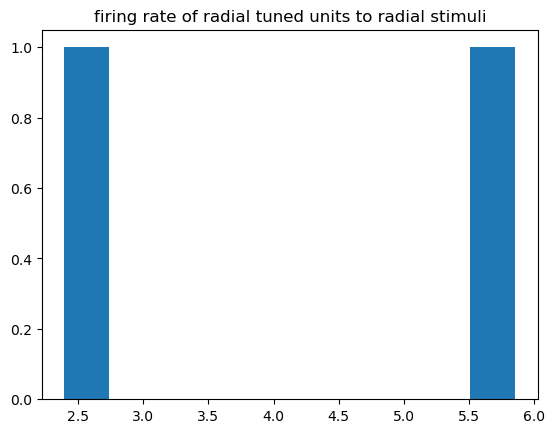

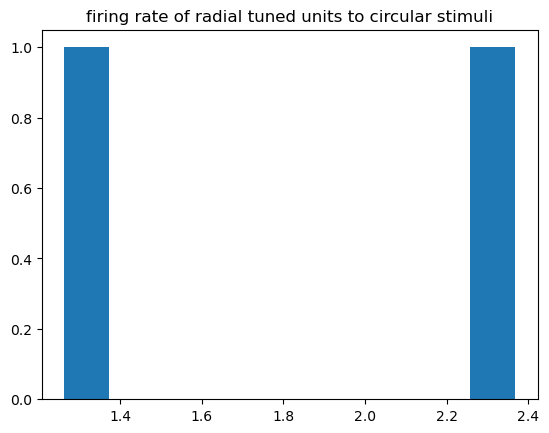

In [24]:
plt.figure()
plt.hist(mean_tuned_circ_to_stim_circ)
plt.title("firing rate of circular tuned units to circular stimuli")

plt.figure()
plt.hist(mean_tuned_circ_to_stim_rad)
plt.title("firing rate of circular tuned units to radial stimuli")

plt.figure()
plt.hist(mean_tuned_rad_to_stim_rad)
plt.title("firing rate of radial tuned units to radial stimuli")

plt.figure()
plt.hist(mean_tuned_rad_to_stim_circ)
plt.title("firing rate of radial tuned units to circular stimuli")

print(np.array(mean_tuned_circ_to_stim_circ).mean(), np.array(mean_tuned_circ_to_stim_rad).mean(), np.array(mean_tuned_rad_to_stim_rad).mean(), np.array(mean_tuned_rad_to_stim_circ).mean())

print(np.array(tuned_circ_to_stim_circ).mean(), np.array(tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ).mean())


2.6587982832618025 1.021543985637343 4.125 1.8157894736842106


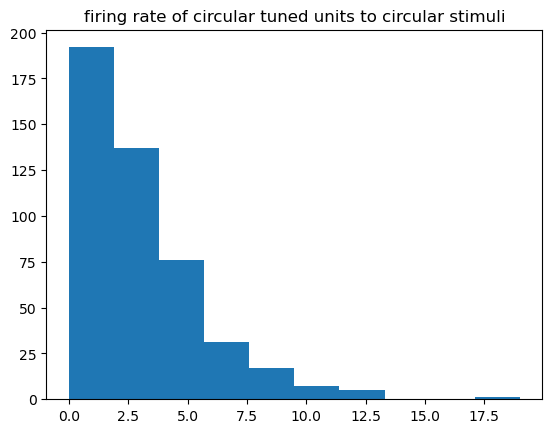

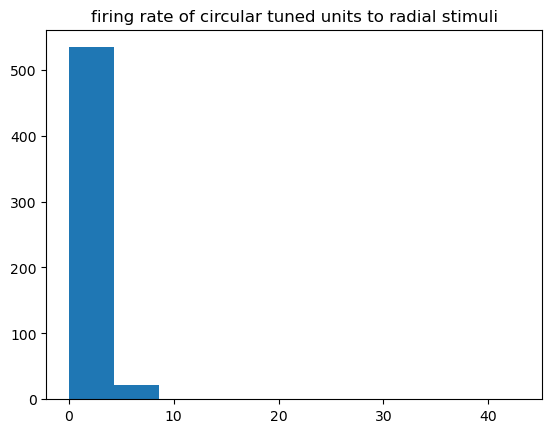

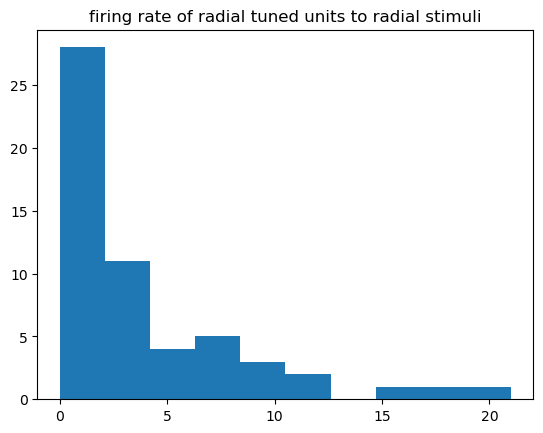

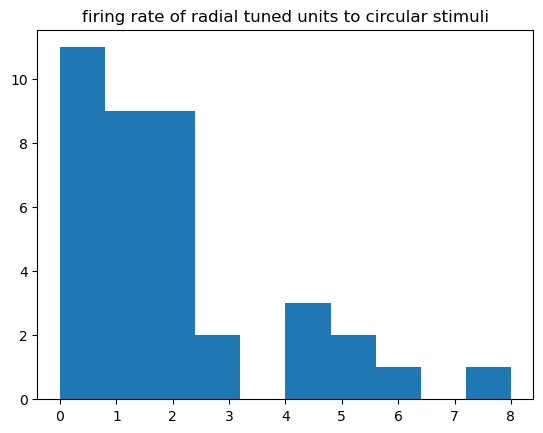

In [25]:
plt.figure()
plt.hist(tuned_circ_to_stim_circ)
plt.title("firing rate of circular tuned units to circular stimuli")

plt.figure()
plt.hist(tuned_circ_to_stim_rad)
plt.title("firing rate of circular tuned units to radial stimuli")

plt.figure()
plt.hist(tuned_rad_to_stim_rad)
plt.title("firing rate of radial tuned units to radial stimuli")

plt.figure()
plt.hist(tuned_rad_to_stim_circ)

plt.title("firing rate of radial tuned units to circular stimuli")

print(np.array(tuned_circ_to_stim_circ).mean(), np.array(tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ).mean())


In [26]:
np.array(tuned_circ_to_stim_circ + tuned_circ_to_stim_rad).mean(), np.array(tuned_rad_to_stim_circ + tuned_rad_to_stim_rad).mean()


(1.7673509286412512, 3.1914893617021276)

In [27]:
#Conclusion: circular: 6/2; radial: 4/2 or 4/3  (neurons tuned to radial firing for circular may have higher firing rates than neurons 
# tuned to circular firing for radial)

In [28]:
tuned_circ_to_stim_circ = np.array(tuned_circ_to_stim_circ)
tuned_circ_to_stim_rad = np.array(tuned_circ_to_stim_rad)
tuned_rad_to_stim_circ = np.array(tuned_rad_to_stim_circ)
tuned_rad_to_stim_rad = np.array(tuned_rad_to_stim_rad)

In [29]:
#Q3: What distribution can I fit for the firing rates of these neurons?

p-value: 2.8043098818953446e-98


/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:6927: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_1564368/1840130122.py:8: RuntimeWarning: divide by zero encountered in log
  stats.probplot(np.log(tuned_circ_to_stim_circ), dist="norm", plot=plt)
/home/dvoina/anaconda3/envs/lightly_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


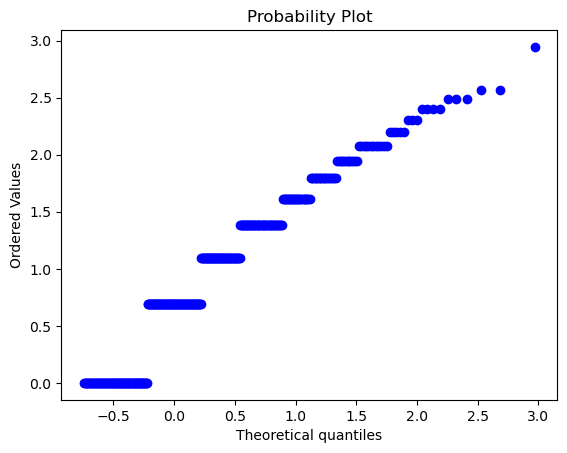

In [30]:
shape, loc, scale = stats.lognorm.fit(tuned_circ_to_stim_circ)

# KS test
stat, p_value = stats.kstest(tuned_circ_to_stim_circ, 'lognorm', args=(shape, loc, scale))
print(f"p-value: {p_value}")  # p > 0.05 → can't reject log-normal

# Q-Q plot on log-transformed data
stats.probplot(np.log(tuned_circ_to_stim_circ), dist="norm", plot=plt)
plt.show()

In [31]:
tuned_circ_to_stim_circ.mean(), tuned_circ_to_stim_circ.var()

(2.6587982832618025, 7.349246624546409)

In [32]:
snr_choice = 1.0

print("FANO FACTORS for circular neurons responding to circular stimuli")
for session in range(1,n_sessions):
    
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_circ:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'circ') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for circular neurons responding to radial stimuli")
for session in range(1,n_sessions):
    
    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_circ:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'rad') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for radial neurons responding to radial stimuli")
for session in range(1,n_sessions):

    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_rad:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'rad') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )

print("--------")
print("FANO FACTORS for radial neurons responding to circular stimuli")
for session in range(1,n_sessions):

    neurons_tuned_circ, neurons_tuned_rad, neurons_untuned = find_tuned_neurons(df_sessions_m1_phase1, session)

    for n in neurons_tuned_rad:
        df = df_sessions_m1_phase1[str(session)][(df_sessions_m1_phase1[str(session)].stim == 'circ') & (df_sessions_m1_phase1[str(session)].snr == snr_choice) & (df_sessions_m1_phase1[str(session)].neuron_id == n)]
        print("session: ", session, "neuron: ", n, "number of trials: ", len(df.firing.values), "fano factors: ", df.firing.values.var()/df.firing.values.mean() )


FANO FACTORS for circular neurons responding to circular stimuli
p_values 0.24486166559927725 0.7558215402590336
p_values 0.9849680515526813 0.015096038121540405
p_values 0.7573726066440614 0.24310624151423615
p_values 0.18149348185887315 0.8188808927587279
p_values 0.015885465118108323 0.9841814644264547
p_values 0.06590007017483734 0.9342922671433972
p_values 0.9916542269393479 0.00837692948193484
p_values 0.926614742113853 0.07357327569492031
p_values 0.5087958651608682 0.4917371388824295
p_values 0.01422606995722351 0.9858249642062543
p_values 2.098280004095471e-05 0.9999791501002941
session:  1 neuron:  5 number of trials:  17 fano factors:  4.92156862745098
session:  1 neuron:  10 number of trials:  17 fano factors:  1.3936651583710407
session:  1 neuron:  11 number of trials:  17 fano factors:  3.958664546899842
p_values 0.8501589502904792 0.1509864688753939
p_values 4.6992352210320364e-05 0.9999538366147467
p_values 1.0661650306128737e-09 0.9999999989533305
p_values 3.533566106

In [33]:
#Conclusion: there are some neurons with Poisson distribution (when Fano factor ~1) and some neurons with negative binomial distribution
# (when Fano factor > 1). This is kind of confusing.|

In [34]:
#prepare dataset on which to do Oja
#there are 93 neurons. For each one, FIX one stimulus and one SNR

In [35]:
snr_choice = [0.65, 0.8, 1.0]  #[0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]

In [36]:
df_all_sessions_m1_phase1 = pd.DataFrame([], columns=["neuron_id", "spike_ts", "firing", "stim", "snr", "pos", "error", "choice", "reaction_time", "trial"])
session_n = pd.DataFrame([], columns=["session"])

total_neurons = 0
for session in range(1,n_sessions+1):
    df_sessions_m1_phase1[str(session)].loc[:, 'neuron_id'] = df_sessions_m1_phase1[str(session)].neuron_id.copy() + total_neurons
    total_neurons += len(np.unique(np.array(df_sessions_m1_phase1[str(session)].neuron_id)))
    
    df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)
    session_n = pd.concat([session_n, pd.DataFrame([session]*len(df_sessions_m1_phase1[str(session)].neuron_id.values), columns=["session"])], axis=0)

df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, session_n], axis=1)

/tmp/ipykernel_1564368/3995063769.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_sessions_m1_phase1 = pd.concat([df_all_sessions_m1_phase1, df_sessions_m1_phase1[str(session)]], axis=0)


In [37]:
choice = "only_session"#"ensamble"

if choice == "ensamble":
    n_neurons = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == "circ") & (df_all_sessions_m1_phase1.snr == snr_choice)].neuron_id.unique())
    list_of_neurons = df_all_sessions_m1_phase1.neuron_id.unique()
    n_trials = 1000
 
    list_of_stim = ["circ", "rad"]
    list_of_stim = list_of_stim * (n_trials//len(list_of_stim))

    print(np.sort(list_of_neurons))

    X_train = np.zeros((n_trials, n_neurons))
    y_train = np.zeros(n_trials)
    animal_choice = np.zeros(n_trials)
    list_of_errors = []
    
    for trial in range(n_trials):
        print("trial", trial)
        selected_trials = []
        for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons))):
            #print("neuron", neuron)
            #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial
            trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].trial

            rand_trial = np.random.randint(0,len(trials))    
            selected_trial =  rand_trial #trial % len(trials) #
            selected_trials.append(selected_trial)
            
            #print("sel trial", selected_trial)
            #firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].firing
            firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].firing
            error = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[selected_trial].error
            
            X_train[trial, neuron_ind] = firing
            list_of_errors.append(error)
            
            #print("error", df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].error)
            #if df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].error==1:
            #    print("WHOA")
        #print("selected_trials", selected_trials)
        sel_trial = np.random.randint(0,len(selected_trials))  
        choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].choice
        animal_choice[trial] = choice
        #print("choice", df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == list_of_stim[trial]) & (df_all_sessions_m1_phase1.snr == snr_choice)].iloc[sel_trial].choice)
        
        if list_of_stim[trial] == "circ":
                y_train[trial] = 1
        elif list_of_stim[trial] == "rad":
                y_train[trial] = 0
        else:
                print("ERROR")
                break
else:

    sess = 3

    list_of_neurons_s = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].neuron_id.unique()
    n_trials_s_circ = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
    n_trials_s_rad = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'rad') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
    n_trials_s = n_trials_s_circ + n_trials_s_rad
    
    n_neurons_s = len(list_of_neurons_s)
    animal_choice = np.zeros(n_trials_s)
    
    print("list of neurons:", list_of_neurons_s)
    print("number of trials: ", n_trials_s, "number of neurons: ", n_neurons_s)

    X_train = np.zeros((n_trials_s, n_neurons_s))
    y_train = np.zeros(n_trials_s)

    trial = 0
    for stimulus in ["circ", "rad"]:
        
        print("stimulus", stimulus, "snr_choice", snr_choice)
        min_trials = np.inf
        for nn in range(n_neurons_s):
            trials_ = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice))  & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[nn])].trial.unique()
            if len(trials_) <= min_trials:
                min_trials = len(trials_)
        print("len(trials)", min_trials)
        
        for t in range(min_trials):
            selected_trial =  trial
            for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons_s))):

                #print("neuron", neuron)
                firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].firing
                X_train[trial, neuron_ind] = firing

                choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].choice
                animal_choice[trial] = choice

                if stimulus == "circ":
                    y_train[trial] = 1
                elif stimulus == "rad":
                    y_train[trial] = 0
                else:
                    print("ERROR")
                    break

            trial += 1

    permuted_trials = np.random.permutation(X_train.shape[0])
    X_train = X_train[permuted_trials,:]
    y_train = y_train[permuted_trials]
    animal_choice = animal_choice[permuted_trials]

    tuning_per_neuron = np.zeros(len(list_of_neurons_s))
    for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons_s))):
        FR_circ = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.neuron_id == neuron) & (df_all_sessions_m1_phase1.session == sess)].firing.values.mean()
        FR_rad = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'rad') & (df_all_sessions_m1_phase1.snr.isin(snr_choice)) & (df_all_sessions_m1_phase1.neuron_id == neuron) & (df_all_sessions_m1_phase1.session == sess)].firing.values.mean()

        tuning_per_neuron[neuron_ind] = (FR_circ - FR_rad)/(FR_circ + FR_rad)
      
#trials in sessions: 17, 13, 19, 19, 26
#neurons in sessions: 11, 8, 14, 7, 10

list of neurons: [33 26 32 24 21 30 28 29 22 27 23 20 31 25]
number of trials:  145 number of neurons:  14
stimulus circ snr_choice [0.65, 0.8, 1.0]
len(trials) 52
stimulus rad snr_choice [0.65, 0.8, 1.0]
len(trials) 93


In [38]:
correct_choice = [1 if df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin([0.65,0.8,1.0])) & (df_all_sessions_m1_phase1.session==sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].stim.iloc[i] == "circ" else 0 for i in range(len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin([0.65,0.8,1.0])) & (df_all_sessions_m1_phase1.session==sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].stim)) ]
real_choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin([0.65,0.8,1.0])) & (df_all_sessions_m1_phase1.session==sess)& (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].choice

(correct_choice - real_choice).sum()#/len(correct_choice)
abs(correct_choice - real_choice).sum(), abs(y_train - animal_choice).sum()

(12, 12.0)

linear regression acc is:  0.496551724137931
p value (Mann Whitney) 0.007868251972197697
SVM accuracy is:  0.3586206896551724
bayes accuracy:  0.6211745244003308


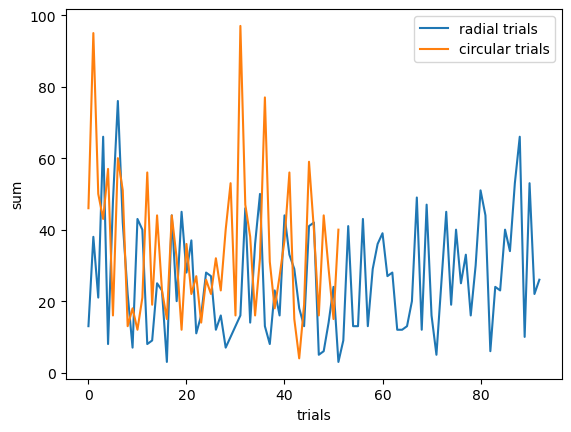

In [39]:
ind0 = np.where(y_train == 0)[0]
ind1 = np.where(y_train == 1)[0]

plt.plot(X_train[ind0,:].sum(1))
plt.plot(X_train[ind1,:].sum(1))
plt.xlabel("trials")
plt.ylabel("sum")
plt.legend(["radial trials", "circular trials"])

#print(X_train[ind0,:].mean(1), X_train[ind1,:].mean(1))
#print(X_train[ind0].sum(), X_train[ind1].sum(), X_train[ind0].mean(), X_train[ind1].mean())
X_train[ind0,:].sum(1), X_train[ind1,:].sum(1)

model = LinearRegression().fit(X_train, y_train)
weights_lr = model.coef_
y_hat = model.predict(X_train)
y_hat = (y_hat>=0.0).astype(int)
print("linear regression acc is: ", 1-np.abs(y_train-y_hat).sum()/len(y_train))

rng = np.random.default_rng()
stat, p_value = mannwhitneyu(np.random.permutation(X_train[ind1,:].sum(1)), np.random.permutation(X_train[ind0,:].sum(1)), alternative='greater')
print("p value (Mann Whitney)", p_value)

xx = list(np.expand_dims(X_train[ind1,:].sum(1), axis=1)) + list(np.expand_dims(X_train[ind0,:].sum(1), axis=1)); yy = list(np.ones(len(ind1))) + list(np.zeros(len(ind0)))
clf = svm.SVC(kernel='linear') # 'linear', 'poly', 'rbf', or 'sigmoid'
clf.fit(xx, yy)
yyy = clf.predict(xx)
print("SVM accuracy is: ", np.abs(yyy-yy).sum()/len(yy))

auc = roc_auc_score(yy, xx)
print("bayes accuracy: ", max(auc, 1-auc))

(array([15., 21., 12., 12.,  8., 15.,  7.,  0.,  2.,  1.]),
 array([ 3. , 10.3, 17.6, 24.9, 32.2, 39.5, 46.8, 54.1, 61.4, 68.7, 76. ]),
 <BarContainer object of 10 artists>)

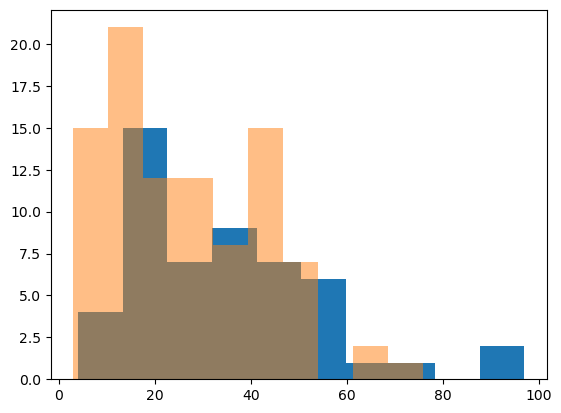

In [40]:
plt.figure()
plt.hist(X_train[ind1,:].sum(1))
plt.hist(X_train[ind0,:].sum(1), alpha=0.5)
         

In [41]:
neurons_circ_new = []
neurons_rad_new = []
neurons_untuned_new = []
for neuron_ind, neuron in enumerate(np.sort(list_of_neurons_s)):
    if neuron in neuron_id_tuned_circular:
        neurons_circ_new.append(neuron_ind)
    elif neuron in neuron_id_tuned_radial:
        neurons_rad_new.append(neuron_ind)
    elif neuron in neuron_id_tuned_untuned:
        neurons_untuned_new.append(neuron_ind)

neurons_circ_new, neurons_rad_new, neurons_untuned_new

([1, 2, 7, 8, 9, 10, 12], [6, 11], [0, 3, 4, 5, 13])

In [42]:
len(list_of_neurons_s)
np.sort(list_of_neurons_s), list_of_neurons_s.shape

(array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33],
       dtype=object),
 (14,))

In [43]:
len(neurons_circ_new), len(neurons_rad_new), len(neurons_untuned_new)

(7, 2, 5)

In [44]:
print("mean activity circular-tuned neurons: ", X_train[:, neurons_circ_new].mean())
print("mean activity radial-tuned neurons: ", X_train[:, neurons_rad_new].mean())
print("sum activity circular-tuned neurons: ", X_train[:, neurons_circ_new].sum())
print("sum activity radial_tuned neurons: ", X_train[:, neurons_rad_new].sum())


mean activity circular-tuned neurons:  1.3113300492610838
mean activity radial-tuned neurons:  3.203448275862069
sum activity circular-tuned neurons:  1331.0
sum activity radial_tuned neurons:  929.0


In [ ]:
plt.figure()
plt.plot(weights_lr, "*-")
plt.plot(weights_lr[neurons_circ_new], "*-")
plt.plot(weights_lr[neurons_rad_new], "*-")
weights_lr[neurons_circ_new].mean(), weights_lr[neurons_rad_new].mean()

In [ ]:
snr_choice

In [ ]:
X_test = X_train[int(len(X_train)*0.8):,:]
y_test = y_train[int(len(X_train)*0.8):]
animal_choice_test = animal_choice[int(len(X_train)*0.8):]

len_ = len(X_train)
X_train = X_train[:int(len_*0.8),:]
y_train = y_train[:int(len_*0.8)]
animal_choice_train = animal_choice[:int(len_*0.8)]

X_test.shape, X_train.shape, y_train.shape

In [ ]:
print("X_train shape:", X_train.shape)
print("Constant columns:", np.where(X_train.std(axis=0) == 0)[0])
print("Any NaN:", np.any(np.isnan(X_train)))

In [ ]:
sess="10"
np.save("X_train_pooya_data_M1_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy", X_train[:800,:])
np.save("y_train_pooya_data_M1_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy", y_train[:800])
np.save("choice_train_pooya_data_M1_phase1_LF_snr"+ str(snr_choice) + "_sess" + str(sess) + ".npy", animal_choice_train)
np.save("X_test_pooya_data_M1_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy", X_test)
np.save("y_test_pooya_data_M1_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy", y_test)
np.save("choice_test_pooya_data_M1_phase1_LF_snr"+ str(snr_choice) + "_sess" + str(sess) + ".npy", animal_choice_test)


In [ ]:
"X_train_pooya_data_M1_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy"

In [ ]:
sess="10"
X_train = np.load("X_train_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")
y_train = np.load("y_train_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")
animal_choice_train = np.load("choice_train_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")

X_test = np.load("X_test_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")
y_test = np.load("y_test_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")
animal_choice_test = np.load("choice_test_pooya_data_phase1_LF_snr" + str(snr_choice) + "_sess" + str(sess) + ".npy")

In [45]:
X_train = torch.tensor(X_train).float(); y_train = torch.tensor(y_train); animal_choice = torch.tensor(animal_choice)

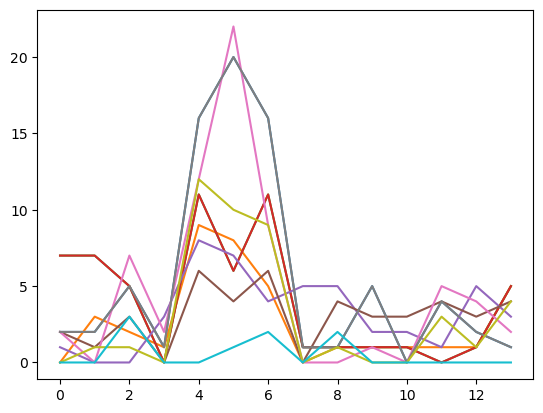

In [46]:
num = np.random.randint(0, X_train.shape[1], size=10)

for i in range(10):
    plt.plot(X_train[num[i],:])

[141.83098   61.0367    41.62977   32.601692  25.00571   23.042803
  19.841852  17.800884  16.100521  14.466595]


Text(0.5, 1.0, 'covariance matrix')

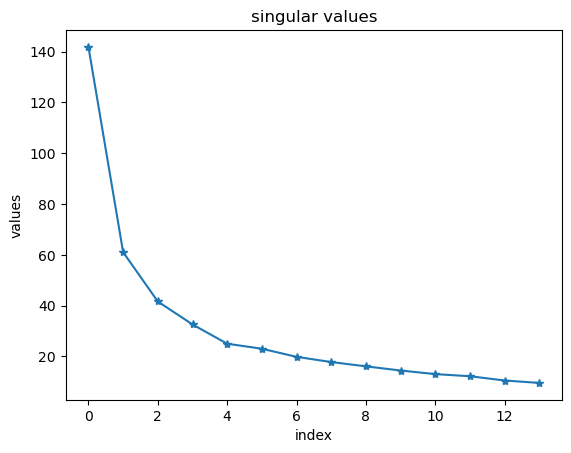

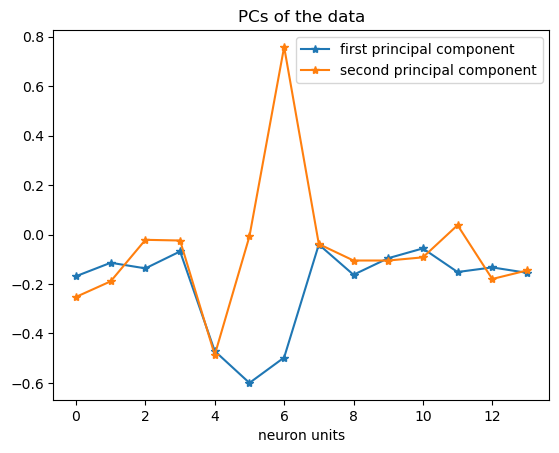

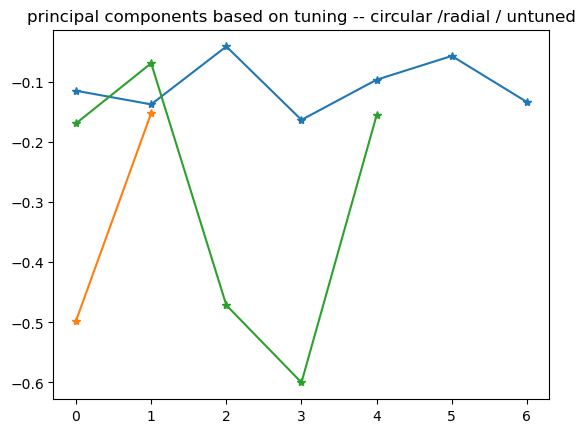

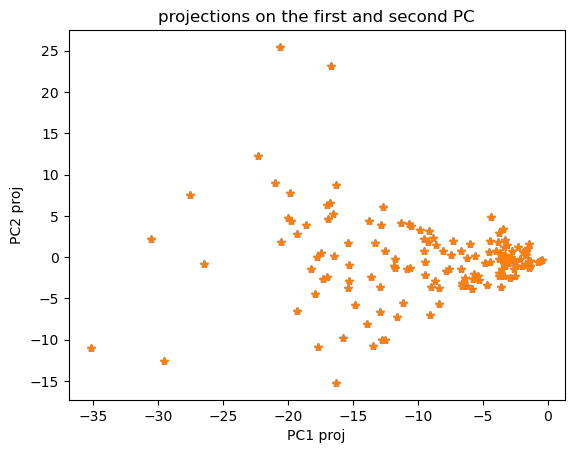

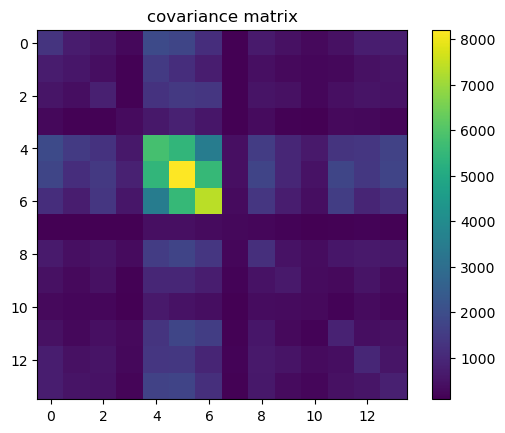

In [48]:
X = X_train #-X_train.mean(0)
cov = X.T @ X
U, s, Vh = np.linalg.svd(X)

plt.plot(s, "*-")
plt.title("singular values")
plt.xlabel("index")
plt.ylabel("values")
print(s[:10])

plt.figure()
plt.plot(Vh[0,:], "*-")
plt.plot(Vh[1,:], "*-")
plt.legend(["first principal component", "second principal component"])
plt.xlabel("neuron units")
plt.title("PCs of the data")

plt.figure()
if neurons_circ_new != []:
    plt.plot(Vh[0,np.array(neurons_circ_new)], "*-")
if neurons_rad_new != []:
    plt.plot(Vh[0,np.array(neurons_rad_new)], "*-")
if neurons_untuned_new != []:
    plt.plot(Vh[0,np.array(neurons_untuned_new)], "*-")
plt.title("principal components based on tuning -- circular /radial / untuned")

plt.figure()
plt.plot(X @ Vh.T[:,0], X @ Vh.T[:,1], "*")
plt.plot(X @ Vh.T[:,0], X @ Vh.T[:,1], "*")
plt.title("projections on the first and second PC")
plt.xlabel("PC1 proj")
plt.ylabel("PC2 proj")

plt.figure()
plt.imshow(cov)
plt.colorbar()
plt.title("covariance matrix")
#neurons_rad_new, neurons_circ_new
#11 + 8 + 14 + 7 + 10 --> session 3 with high covariance

In [ ]:
ind0 = np.where(y_train ==0)[0]
ind1 = np.where(y_train ==1)[0]

acc_after_deletion = []
shape_after_deletion = []

for n_del in [1,2,3,5,7]:
    print(n_del)
    for t in range(100):
        #X_train = np.load("X_train_pooya_data_phase1_LF_snr1_sess" + str(sess) + "npy")
        #y_train = np.load("y_train_pooya_data_phase1_LF_snr1_sess" + str(sess) + ".npy")

        remove_neurons = np.random.randint(0, X_train.shape[1], size=n_del)
        new_X_train = np.delete(X_train, remove_neurons, axis=1)
                        
        shape_after_deletion.append(new_X_train.shape[1])
    
        U, s, Vh = np.linalg.svd(new_X_train)
        w = Vh[0,:]
        #w = (1+np.random.randn(new_X_train.shape[1]))/new_X_train.shape[1]
        #W1 = np.concatenate([np.expand_dims(w,1)]*2*len(w), axis = 1)

        y = new_X_train @ w
        b = - y.mean()

        y = y + b
        acc = float( (y[ind0] <= 0).sum() + (y[ind1] >= 0).sum() ) / len(y)
        acc_after_deletion.append(acc)


plt.figure()
plt.plot(shape_after_deletion, acc_after_deletion, "*")

df = pd.DataFrame({'shape':shape_after_deletion, 'acc': acc_after_deletion})
df['Bins'] = pd.cut(df['shape'], bins=10)  # adjust number of bins as needed
result = df.groupby('Bins', observed=True)['acc'].mean()

plt.figure()
plt.plot(result.values)

In [ ]:
ind0 = np.where(y_train ==0)[0]
ind1 = np.where(y_train ==1)[0]

neurons_circ_New = []
neurons_rad_New = []
neurons_untuned_New = []
for i in range(X_train.shape[1]):
    stat, p_value1 = mannwhitneyu(X_train[ind0,i].squeeze(), X_train[ind1,i].squeeze(), alternative='greater')
    stat, p_value2 = mannwhitneyu(X_train[ind1,i].squeeze(), X_train[ind0,i].squeeze(), alternative='greater')
    print(i, p_value1, p_value2)

    if p_value1<0.05:
        neurons_rad_New.append(i)
    if p_value2<0.05:
        neurons_circ_New.append(i)
    if p_value1>0.05 and p_value2>0.05:
        neurons_untuned_New.append(i)

neurons_circ_New, neurons_rad_New, neurons_untuned_New

In [ ]:
#train with Oja

In [ ]:
def train_oja_unsupervised(features, student_w_init = None, add_bias=False):

    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    if add_bias:
        features = features - features.mean(0)
    
    if student_w_init is not None:
        student_w = student_w_init
    else:
        student_w = torch.ones(1, n_total) * 0.01 #torch.randn(1, n_total) * 0.01
        
    print("student_w", student_w)
    student_b = torch.ones(1)
    eta = 0.0001
    print("eta", eta, student_w.mean())
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    with torch.no_grad():
        for j in range(1000):
            print("j", j)
            y_arr = []
            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                if add_bias:
                    y_student = torch.matmul(student_w, x_i.T)[0].item() + student_b
                else:
                     y_student = torch.matmul(student_w, x_i.T)[0].item()
                dw = eta * (y_student * x_i - (y_student**2) * student_w)
                student_w += dw

                
                #learn bias
                y_new = torch.matmul(student_w, x_i.T)[0].item() + student_b
                ybar = y_new #(1 - alpha) * ybar + alpha * y_new
                student_b += eta*(-ybar) #y_target=0
                
                if np.isnan(student_w.sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b, eta

In [ ]:
def train_oja_unsupervised_gd(features, y_true, student_w_init = None, add_bias=False):

    features = torch.as_tensor(features, dtype=torch.float32)
    y_true = torch.as_tensor(y_true, dtype=torch.float32)
    
    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    y_true = y_true[rand_ind]
    features = features - features.mean(0)
    
    if student_w_init is not None:
        student_w = student_w_init
    else:
        student_w = torch.randn(1, n_total) * 0.01 #torch.ones(1, n_total) * 0.01
        
    student_b = nn.Parameter(torch.tensor(0.0), requires_grad=True)
    eta = 0.1
    total_loss = 0
    
    optimizer = optim.Adam([student_b], lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    #with torch.no_grad():
    for j in range(1000):
            print("j", j)
            y_arr = []

            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                with torch.no_grad():
                    y_oja = torch.matmul(student_w, x_i.T).squeeze().item()

                    if add_bias:
                        y_student = y_oja + student_b
                    else:
                        y_student = y_oja
                        
                    dw = eta * (y_oja * x_i - (y_oja**2) * student_w)
                    student_w += dw
                    
                optimizer.zero_grad()

                logit = torch.matmul(student_w, x_i.T).squeeze() + student_b
                target = y_true[i].squeeze()

                # target must be 0/1 float for BCE
                loss = bce(logit.view(1), target.view(1))

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                if np.isnan(student_w.detach().numpy().sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b, eta

In [ ]:
def train_gd(features, y_true, student_w_init = None, add_bias=False):

    features = torch.as_tensor(features, dtype=torch.float32)
    y_true = torch.as_tensor(y_true, dtype=torch.float32)
    
    n_samples = features.shape[0]
    n_total = features.shape[1]
    rand_ind = np.random.permutation(np.arange(n_samples))
    features = features[rand_ind, :];
    y_true = y_true[rand_ind]
    features = features - features.mean()
    
    if student_w_init is not None:
        student_w = nn.Parameter(student_w_init, requires_grad=True)
    else:
        student_w = nn.Parameter(torch.randn(1, n_total) * 0.01)
        
    student_b = nn.Parameter(torch.tensor(0.0), requires_grad=True)
    eta = 0.0001
    total_loss = 0
    
    optimizer = optim.Adam([student_w, student_b], lr=1e-3)
    bce = nn.BCEWithLogitsLoss()
    
    acc_arr = []; 
    print("Student learning via Oja's Rule...")
    #with torch.no_grad():
    for j in range(1000):
            print("j", j)
            y_arr = []

            for i in range(features.shape[0]):
                x_i = features[i].squeeze().unsqueeze(0)

                y_pred = torch.matmul(student_w, x_i.T).squeeze().item() + student_b
                target = y_true[i].squeeze()

                optimizer.zero_grad()

                # target must be 0/1 float for BCE
                loss = bce(y_pred.view(1), target.view(1))

                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                if np.isnan(student_w.detach().numpy().sum()):
                    print("hello")
                    return

                #if i%100:
                #    print("student_b", student_b)
    #y_new = torch.matmul(student_w, features.T)
    #student_b = y_new.mean()
    return student_w, student_b

In [ ]:
#student_w, student_b, eta = train_oja_unsupervised_gd(torch.tensor(X_train).float(), y_train, add_bias=False)
student_w, student_b, eta = train_oja_unsupervised(torch.tensor(X_train).float(), add_bias=True)
#student_w, student_b = train_gd(torch.tensor(X_train).float(), y_train, add_bias=True)

In [ ]:
student_w = student_w.squeeze()

plt.plot(student_w.detach().numpy())
plt.plot(-Vh[0,:])
plt.title("w versus PC1 for various tuned neurons")
plt.legend(["w", "PC1"])
plt.xlabel("weight index")
plt.ylabel("weight value")

plt.figure()
if neurons_circ_new != []:
    plt.plot(student_w.detach().numpy()[np.array(neurons_circ_new)], "*-")
if neurons_rad_new != []:
    plt.plot(student_w.detach().numpy()[np.array(neurons_rad_new)], "*-")
if neurons_untuned_new != []:
    plt.plot(student_w.detach().numpy()[np.array(neurons_untuned_new)], "*-")
plt.xlabel("weight index")
plt.ylabel("weight value")
plt.legend(["circular neurons", "radial neurons", "untuned neurons"])
plt.title("w for various tuned neurons")
#
if neurons_circ_new != []:
    plt.figure()
    plt.plot(student_w.detach().numpy()[np.array(neurons_circ_new)], "*-")
    plt.plot(-Vh[0,np.array(neurons_circ_new)], "*-")
    plt.title("w versus PC1 for circular tuned neurons")
    plt.legend(["w", "PC1"])

if neurons_rad_new != []:
    plt.figure()
    plt.plot(student_w.detach().numpy()[np.array(neurons_rad_new)], "*-")
    plt.plot(-Vh[0,np.array(neurons_rad_new)], "*-")
    plt.title("w versus PC1 for radial tuned neurons")
    plt.legend(["w", "PC1"])

print("mean weights: ", student_w[np.array(neurons_circ_new)].mean(), student_w[np.array(neurons_rad_new)].mean(), student_w[np.array(neurons_untuned_new)].mean())
print("std weights: ", student_w[np.array(neurons_circ_new)].std(), student_w[np.array(neurons_rad_new)].std(), student_w[np.array(neurons_untuned_new)].std())
print("total mean: ", student_w.mean())                                                                                                                 
student_b

In [ ]:
#student_w_copy = student_w.clone()
#student_w[np.array(neurons_rad_new)] = 0.36  #-0.07#-student_w[np.array(neurons_circ_new)].mean()
#student_w[np.array(neurons_circ_new)] = -0.15  #w_gd[np.array(neurons_rad_new),0]
#student_w[np.array(neurons_untuned_new)] = 0
#student_b = torch.tensor(-21)
#student_w = 0.1*(1+np.random.randn(X_train.shape[1]))
#student_w = 0.1*np.ones(X_train.shape[1])
#student_w[np.array(neurons_rad_new)] = -0.1
#student_w[np.array(neurons_circ_new)] = 0.1
#student_w[8] = 0
student_w = -Vh[0,:]

In [ ]:
student_b, student_w

In [ ]:
#how good, i.e. accurate is this solution?
features = X_train #- X_train.numpy().mean(0) 
y = y_train

bb = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w).squeeze().float()).mean()
print("bb", bb, "versus student_b", student_b)
y_exp = torch.matmul(torch.tensor(features).float(), torch.tensor(student_w).squeeze().float()) + student_b

ind0 = np.where(y == 0)[0]
ind1 = np.where(y == 1)[0]

y_exp = y_exp.detach().numpy()
plt.plot(y_exp[ind0])
plt.plot(y_exp[ind1])
plt.xlabel("trials")
plt.ylabel("model output")

float( (y_exp[ind0] <= 0).sum() + (y_exp[ind1] >= 0).sum() ) / len(y_exp), (y_exp<=0).sum(), (y_exp>=0).sum()

In [ ]:
#student_w = -student_w
student_b = student_b+8 #torch.tensor(5)

In [ ]:
#features = X_train #- X_test.mean(0)
#y_new = torch.matmul(torch.tensor(student_w).float(), torch.tensor(features).float().T)
#student_b2 = y_new.mean()
#student_b2, student_b

In [ ]:
#compute choice probability for this solution w

In [ ]:
def compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, min_per_choice=6, min_wrong=3, force_ge_half=False, eps=1e-8):

    # features: (T, N) or (1,T,N) etc -> make (T, N)
    X = features.squeeze()
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    
    y = np.asarray(y.squeeze())
    n_stim = 2

    # logits + choice
    out = (student_w @ X.T + student_b)
    
    if isinstance(out, torch.Tensor):
        out = out.detach().cpu().numpy()
    out = np.asarray(out).ravel()

    threshold = 0.0   #if crit == "MSE" else 0.0
    choice = (out >= threshold).astype(int)
    
    if crit != "BCE":
        choice = 2*choice - 1

    if choose_y != "model":
        choice = animal_choice

    #print("animal_choice", animal_choice)
    #print(animal_choice - y)
    #print("choice", choice)
        
    neurons_tuned_stim1, neurons_tuned_stim0, neurons_untuned = tunings
    neurons_tuned_list = list(neurons_tuned_stim1) + list(neurons_tuned_stim0)

    # sample up to 1000 neurons
    #rng = np.random.default_rng(0)
    #if len(neurons_tuned_list) > n_neurons:
    #    neurons_tuned_list = list(rng.choice(neurons_tuned_list, size=n_neurons, replace=False))

    # allocate by LOOP INDEX (safe)
    CP_arr = np.full((len(neurons_tuned_list), n_stim), np.nan)
    new_tunings = []

    list_of_stim = [0, 1] if crit == "BCE" else [-1, 1]
    
    for i, n in enumerate(neurons_tuned_list):

        pref = (0 if crit == "BCE" else -1) if n in neurons_tuned_stim0 else (1)            
        new_tunings.append(pref)
        
        for s in list_of_stim:
            
            idx = np.where(y == s)[0]
            if idx.size == 0:
                continue

            r_raw = X_np[idx, n]                  # raw firing rates this condition
 
            # FIX 4: z-score within condition to remove mean stimulus drive
            mu, sd = r_raw.mean(), r_raw.std()
            r = (r_raw - mu) / (sd + eps) if sd > eps else r_raw - mu
            #r = r_raw
            
            o = (choice[idx] == pref).astype(int)  # labels: 1 = preferred choice
                
            n1 = int(o.sum())
            n0 = int((1 - o).sum())
            print("choice is preferred, or unpreferred", n0, n1)
            wrong = np.sum(choice[idx] != y[idx])
            print("wrong", wrong)
            #wrong = min(n0, n1)  # proxy if you don't have correctness labels

            if n1 < min_per_choice or n0 < min_per_choice or wrong < min_wrong:
            #if len(idx) < min_per_choice or wrong < min_wrong:
               print("OH nooo, the classifier i just too good and doesn't make mistakes")
               continue

            print("o", "r", o, r)
            auc = roc_auc_score(o, r)  # <-- correct order
            print("auc", auc, 1-auc)
            if force_ge_half:
                auc = max(auc, 1 - auc)

            s_idx = 0 if s in (-1, 0) else 1
            CP_arr[i, s_idx] = auc

    cp = np.nanmean(CP_arr, axis=1)  # mean across stim, per sampled neuron
    return cp, CP_arr, neurons_tuned_list, new_tunings

def compute_noise_corr(features, y, neurons, zclip=3.0, eps=1e-8):
    X = np.asarray(features.squeeze())[:, neurons]          # (T, K)
    stim = np.asarray(y).ravel()

    Z = np.empty_like(X, dtype=float)

    # z-score within stimulus condition (removes mean/scale per stimulus)
    for s in np.unique(stim):
        idx = np.where(stim == s)[0]
        mu = X[idx].mean(axis=0)
        sd = X[idx].std(axis=0) + eps
        Z[idx] = (X[idx] - mu) / sd

    # ±3 SD trimming (their rule; easiest is drop trials with any extreme value)
    keep = np.all(np.abs(Z) <= zclip, axis=1)
    Z = Z[keep]

    # Pearson correlation matrix across neurons
    # (np.corrcoef uses columnwise corr if rowvar=False)
    C = np.corrcoef(Z, rowvar=False)              # (K, K)
    return C, Z

def compute_readout_weights(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, eps=1e-7, normalize = False):

    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y, animal_choice)
    C, Z = compute_noise_corr(features, y, neurons_tuned_list)

    C = np.asarray(C, dtype=float)
    cp = np.asarray(cp, dtype=float).ravel()

    try:
        diag = np.clip(np.diag(C), eps, None)
    except:
        diag = np.clip(np.diag([C]), eps, None)

    rhs  = (np.pi * np.sqrt(diag) * (cp - 0.5)) / np.sqrt(2) #np.sqrt(diag) * (cp - 0.5)
    
    # Solve C beta = v  (preferred over inv(C) @ v)
    try:
        beta = solve(C, rhs, assume_a="sym") #rhs
    except np.linalg.LinAlgError:
        beta, *_ = np.linalg.lstsq(C, rhs, rcond=None)

    if normalize:
        denom = np.sqrt(beta.T @ C @ beta) + eps
        beta = beta / denom

    return beta


In [ ]:
crit = "BCE"
n_neurons = X_train.shape[1]
tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]

#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)
#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(X_test).float(), y_test, tunings, crit, n_neurons)
#readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(X_test).float(), y_test, tunings, crit, n_neurons)

cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)


In [ ]:
cp.mean(), readout_weights.mean(), print("cp: ", cp, "\n readout_weights: \n", readout_weights)

In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[:len(tunings[0])].mean()-0.5, cp[len(tunings[0]):].mean()-0.5])


In [ ]:
plt.plot(readout_weights[:len(tunings[0])])
plt.plot(readout_weights[len(tunings[0]):])

In [ ]:
def compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, min_per_choice=6, min_wrong=3, force_ge_half=False, eps=1e-8):

    # features: (T, N) or (1,T,N) etc -> make (T, N)
    X = features.squeeze()
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    
    y = np.asarray(y.squeeze())
    n_stim = 2

    # logits + choice
    out = (student_w @ X.T + student_b)
    
    if isinstance(out, torch.Tensor):
        out = out.detach().cpu().numpy()
    out = np.asarray(out).ravel()

    threshold = 0.0   #if crit == "MSE" else 0.0
    choice = (out >= threshold).astype(int)
    
    if crit != "BCE":
        choice = 2*choice - 1

    if choose_y != "model":
        choice = animal_choice

    # allocate by LOOP INDEX (safe)
    CP_arr = np.full((len(student_w), n_stim), np.nan)
    new_tunings = []

    list_of_stim = [0, 1] if crit == "BCE" else [-1, 1]
    neurons_tuned_list = np.sort(np.array(list(tunings[0]) + list(tunings[1]) + list(tunings[2])))
    
    for n in neurons_tuned_list:

        pref = 1          
        
        for s in list_of_stim:
            
            idx = np.where(y == s)[0]
            if idx.size == 0:
                continue

            r_raw = X_np[idx, n]                  # raw firing rates this condition
 
            # FIX 4: z-score within condition to remove mean stimulus drive
            mu, sd = r_raw.mean(), r_raw.std()
            r = (r_raw - mu) / (sd + eps) if sd > eps else r_raw - mu
            
            o = (choice[idx] == pref).astype(int)  # labels: 1 = preferred choice
                
            n1 = int(o.sum())
            n0 = int((1 - o).sum())
            print("choice is preferred, or unpreferred", n0, n1)
            wrong = np.sum(choice[idx] != y[idx])
            print("wrong", wrong)

            if n1 < min_per_choice or n0 < min_per_choice or wrong < min_wrong:
               print("OH nooo, the classifier i just too good and doesn't make mistakes")
               continue

            print("o", "r", o, r)
            auc = roc_auc_score(o, r)  # <-- correct order
            print("auc", auc, 1-auc)
            if force_ge_half:
                auc = max(auc, 1 - auc)

            s_idx = 0 if s in (-1, 0) else 1
            CP_arr[n, s_idx] = auc

    cp = np.nanmean(CP_arr, axis=1)  # mean across stim, per sampled neuron
    return cp, CP_arr, neurons_tuned_list, new_tunings

def compute_noise_corr(features, y, neurons, zclip=3.0, eps=1e-8):
    X = np.asarray(features.squeeze())[:, neurons]          # (T, K)
    stim = np.asarray(y).ravel()

    Z = np.empty_like(X, dtype=float)

    # z-score within stimulus condition (removes mean/scale per stimulus)
    for s in np.unique(stim):
        idx = np.where(stim == s)[0]
        mu = X[idx].mean(axis=0)
        sd = X[idx].std(axis=0) + eps
        Z[idx] = (X[idx] - mu) / sd

    # ±3 SD trimming (their rule; easiest is drop trials with any extreme value)
    keep = np.all(np.abs(Z) <= zclip, axis=1)
    Z = Z[keep]

    # Pearson correlation matrix across neurons
    # (np.corrcoef uses columnwise corr if rowvar=False)
    C = np.corrcoef(Z, rowvar=False)              # (K, K)
    return C, Z

def compute_readout_weights(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, eps=1e-7, normalize = False):

    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y, animal_choice)
    C, Z = compute_noise_corr(features, y, neurons_tuned_list)

    C = np.asarray(C, dtype=float)
    cp = np.asarray(cp, dtype=float).ravel()

    try:
        diag = np.clip(np.diag(C), eps, None)
    except:
        diag = np.clip(np.diag([C]), eps, None)

    rhs  = (np.pi * np.sqrt(diag) * (cp - 0.5)) / np.sqrt(2) #np.sqrt(diag) * (cp - 0.5)
    
    # Solve C beta = v  (preferred over inv(C) @ v)
    try:
        beta = solve(C, rhs, assume_a="sym") #rhs
    except np.linalg.LinAlgError:
        beta, *_ = np.linalg.lstsq(C, rhs, rcond=None)

    if normalize:
        denom = np.sqrt(beta.T @ C @ beta) + eps
        beta = beta / denom

    return beta


In [ ]:
crit = "BCE"
n_neurons = X_train.shape[1]
tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]

#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)
#cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(X_test).float(), y_test, tunings, crit, n_neurons)
#readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(X_test).float(), y_test, tunings, crit, n_neurons)

cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons)


In [ ]:
tuning_per_neuron
plt.plot(tuning_per_neuron, cp, "*")

res_pearson = pearsonr(tuning_per_neuron, cp)
res_spearman = spearmanr(tuning_per_neuron, cp)
print("CP: pearson results (stat +pvalue)", res_pearson.statistic, res_pearson.pvalue)
print("CP: spearman results (stat +pvalue)", res_spearman.statistic, res_spearman.pvalue)

plt.plot(tuning_per_neuron, readout_weights, "*")

res_pearson = pearsonr(tuning_per_neuron, readout_weights)
res_spearman = spearmanr(tuning_per_neuron, readout_weights)

print("RW: pearson results (stat + pvalue)", res_pearson.statistic, res_pearson.pvalue)
print("RW: spearman results (stat + pvalue)", res_spearman.statistic, res_spearman.pvalue)


In [ ]:
cp.mean(), readout_weights.mean(), print("cp: ", cp, "\n readout_weights: \n", readout_weights)

In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[tunings[0]].mean(), readout_weights[tunings[1]].mean()])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[tunings[0]].mean()-0.5, cp[tunings[1]].mean()-0.5])


In [ ]:
crit = "BCE"

cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(weights_lr).float(), torch.tensor(-0.5), torch.tensor(features).float(), y, tunings, crit, n_neurons)#, animal_choice=animal_choice)
readout_weights = compute_readout_weights(torch.tensor(weights_lr).float(), torch.tensor(-0.5), torch.tensor(features).float(), y, tunings, crit, n_neurons)#, animal_choice=animal_choice)


In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[:len(tunings[0])].mean()-0.5, cp[len(tunings[0]):].mean()-0.5])


In [ ]:
crit = "BCE"
#X = X_test[:800,:]
#y = y_test[:800]
#a_choice = animal_choice_test
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice.numpy())
readout_weights = compute_readout_weights(torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice.numpy())


In [ ]:
#cp.mean(), readout_weights.mean(), print("cp: ", cp, "\n readout_weights: \n", readout_weights)

In [ ]:
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[:len(tunings[0])].mean()-0.5, cp[len(tunings[0]):].mean()-0.5])


In [ ]:
readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()

In [ ]:
#yy = torch.tensor(student_w).float() @ torch.tensor(features).float().T + student_b
#(yy.numpy() <= 0).astype(int)



In [ ]:
def find_bias_simple(p, student_w, student_b, features, y, crit="BCE", comparison="heuristic"):
        print("p", p)
        mean = features.clone().mean(0).numpy()
        features_sparse = features.squeeze().numpy().copy() #- mean
        m, n = features_sparse.shape
        
        for i in range(m):
            rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
            features_sparse[i,rand_zeros] = 0
            #print(list(set(rand_zeros) & set(neurons_circ_new)), student_w[list(set(rand_zeros) & set(neurons_circ_new))], features[i,list(set(rand_zeros) & set(neurons_circ_new))], student_w[list(set(rand_zeros) & set(neurons_circ_new))].dot(features[i,list(set(rand_zeros) & set(neurons_circ_new))]))

        #features_sparse = features_sparse - mean #features_sparse.mean(0)
    
        logits = torch.matmul(student_w, torch.from_numpy(features_sparse.T)) + student_b
        logits_nonsparse = torch.matmul(student_w, features.T) + student_b
    
        y = y.squeeze(); logits = logits.squeeze(); logits_nonsparse = logits_nonsparse.squeeze();
        
        if comparison == "heuristic":
            ind0 = np.where(y == 0)[0] 
            ind1 = np.where(y == 1)[0]
        else:
            print('hello')
            ind0 = np.where(y == -1)[0] 
            ind1 = np.where(y == 1)[0] 

        if crit == "BCE":
            ind0 = np.where(y == 0)[0] 
            ind1 = np.where(y == 1)[0] 

        y_res = logits.detach().numpy() - student_b.item()
        plt.figure()
        plt.plot(y_res[ind0])
        plt.plot(y_res[ind1])
        plt.plot(-student_b * np.ones(len(y)))
        plt.xlabel("trials")
        plt.ylabel("output of model")
        plt.legend(["trials, stim 0 (under-rep)", "trials, stim 1 (over-rep)"])
        plt.show()

        print("criteria is: ", crit)
        if crit == "BCE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == 0).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == 0).sum() + (y[logits < threshold] == 1).sum() )/len(y)

            acc1_nonsparse = ( (y[logits_nonsparse < threshold] == 0).sum() + (y[logits_nonsparse > threshold] == 1).sum() )/len(y)
            acc2_nonsparse = ( (y[logits_nonsparse > threshold] == 0).sum() + (y[logits_nonsparse < threshold] == 1).sum() )/len(y)

        elif crit == "MSE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == -1).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == -1).sum() + (y[logits < threshold] == 1).sum() )/len(y)

            acc1_nonsparse = ( (y[logits_nonsparse < threshold] == -1).sum() + (y[logits_nonsparse > threshold] == 1).sum() )/len(y)
            acc2_nonsparse = ( (y[logits_nonsparse > threshold] == -1).sum() + (y[logits_nonsparse < threshold] == 1).sum() )/len(y)

        print("acc1, acc2", acc1, acc2)
        if acc1 == acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2)
            return acc2, (logits>threshold).sum()
            
        if acc1_nonsparse < acc2_nonsparse: #student_w.mean()< 0: #
            print("given p=", str(p) + ", then accuracy is: ", acc2, "class 1 labels (under-represented)", (logits>=threshold).sum(), "class 2 labels (over-represented)", (logits<threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc2, (logits>=threshold).sum()
        else:
            print("given p=", str(p) + ", then accuracy is: ", acc1, "class 1 labels (under-represented)", (logits<=threshold).sum(), "class 2 labels (over-represented)", (logits>threshold).sum())
            print("means of classes: ", logits[ind0].mean(), logits[ind1].mean())
            print("std of classes: ", logits[ind0].std(), logits[ind1].std())
            return acc1, (logits<=threshold).sum()


In [ ]:
class_imbalance = []
for p in [0.0001, 0.3, 0.5, 0.75, 0.9]:
    acc, under_rep_imbalance = find_bias_simple(p, torch.tensor(student_w).float(), student_b, torch.tensor(features).float(), y_train)
    class_imbalance.append(under_rep_imbalance)

In [ ]:
#neurons_imbalance = [675/1000, 894/1000, 987/1000, 999/1000]
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], np.array(class_imbalance)/X_train.shape[0], "*-")
plt.xlabel("probability", fontsize=16)
plt.ylabel("class imbalance", fontsize=16)

In [ ]:
#What about CP for a sum solution? (to compare)

In [ ]:
student_w = torch.ones(X_train.shape[1])
student_b = -X_train.mean(0).sum()

out = (student_w @ X_train.T + student_b)

ind0 = np.where(y_train == 0)[0]
ind1 = np.where(y_train == 1)[0]

plt.plot(out[ind0])
plt.plot(out[ind1])

float( (out[ind0] <= 0).sum() + (
    out[ind1] >= 0).sum() ) / len(out)

In [ ]:
class_imbalance = []
for p in [0.0001, 0.3, 0.5, 0.75, 0.9]:
    acc, under_rep_imbalance = find_bias_simple(p, torch.tensor(student_w).T, torch.tensor(student_b), torch.tensor(X_train).float(), y_train)
    class_imbalance.append(under_rep_imbalance)

In [ ]:
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.ones(X_train.shape[1]), -X_train.mean(0).sum(), X_train, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(torch.ones(X_train.shape[1]), -X_train.mean(0).sum(), X_train, y_train, tunings, crit, n_neurons)



In [ ]:
plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])


plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[:len(tunings[0])].mean()-0.5, cp[len(tunings[0]):].mean()-0.5])


In [ ]:
#What about the distributd readout solution? CP?
student_w = torch.ones(X_train.shape[1])
student_b = -X_train.mean(0).sum()

ind_circular = np.array(neurons_circ_new)
ind_radial = np.array(neurons_rad_new)
ind_untuned = np.array(neurons_untuned_new)

student_w[ind_circular] = 0.1
student_w[ind_radial] = -0.1
student_w[ind_untuned] = 0.0

student_b = 0
out = (student_w @ X_train.T + student_b)

ind0 = np.where(y_train == 0)[0]
ind1 = np.where(y_train == 1)[0]

plt.figure()
plt.plot(out[ind0])
plt.plot(out[ind1])

float( (out[ind0] <= 0).sum() + (out[ind1] >= 0).sum() ) / len(out)

In [ ]:
neurons_circ_new, neurons_rad_new

In [ ]:
cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(student_w, student_b, X_train, y_train, tunings, crit, n_neurons)


In [ ]:
plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [readout_weights[:len(tunings[0])].mean(), readout_weights[len(tunings[0]):].mean()])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [cp[:len(tunings[0])].mean()-0.5, cp[len(tunings[0]):].mean()-0.5])


In [ ]:
class_imbalance = []
for p in [0.0001, 0.3, 0.5, 0.75, 0.9]:
    acc, under_rep_imbalance = find_bias_simple(p, torch.tensor(student_w).T, torch.tensor(student_b), torch.tensor(X_train).float(), y_train)
    class_imbalance.append(under_rep_imbalance)

In [ ]:
plt.plot([0.0001, 0.3, 0.5, 0.75, 0.9], np.array(class_imbalance)/X_train.shape[0], "*-")

In [ ]:
#Gradient descent 

In [ ]:
X_train = np.load("X_train_pooya_data_phase1_LF_snr1_sess" + str(sess) + ".npy")
y_train = np.load("y_train_pooya_data_phase1_LF_snr1_sess" + str(sess) + ".npy")
choice = np.load("choice_pooya_data_phase1_LF_snr1_sess" + str(sess) + ".npy")
y_train

In [ ]:
y_train = 2*y_train - 1
#y_test = 2*y_test - 1

#choice = 2*choice - 1
y_train
#X_train = X_train - X_train.mean(0)

In [ ]:
def train_linear_model(
    X,
    y,
    lr=1e-2,
    n_epochs=50,
    loss_type="mse",  # "mse" or "bce"
    verbose=True,
):
    """
    Train a linear model y = XW + b using gradient descent (optimizer-based).
    """

    N, d = X.shape

    # Ensure y has shape (N, 1)
    if y.ndim == 1:
        y = y.unsqueeze(1)
    
    # Initialize parameters
    W = torch.full((d, 1), 1.0, requires_grad=True)  #torch.ones(d, 1, requires_grad=True) #torch.randn(d, 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)

    # Optimizer (this replaces manual updates)
    optimizer = torch.optim.SGD([W, b], lr=lr)

    for epoch in range(n_epochs):
        # Forward pass
        y_pred = X @ W + b  # (N, 1)

        if loss_type == "mse":
            loss = torch.mean((y_pred - y) ** 2)

        elif loss_type == "bce":
            loss_bce = nn.BCELoss()

            y_pred_sigmoid = torch.sigmoid(y_pred)
            loss = loss_bce(y_pred_sigmoid, y)
                    #torch.mean(-y * torch.log(y_pred_sigmoid + 1e-8) - (1 - y) * torch.log(1 - y_pred_sigmoid + 1e-8))

        else:
            raise ValueError("loss_type must be 'mse' or 'bce'")

        # Backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f"Epoch {epoch}: loss = {loss.item():.4f}")

    return W.detach(), b.detach()

In [ ]:
#X_train = X_train.detach().numpy()
#y_train = y_train.detach().numpy()
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)

In [ ]:
X_test = X_train
y_test = y_train

In [ ]:
#X_train = torch.from_numpy(X_train).float()
#y_train = torch.from_numpy(y_train).float()

method = "mse"
w_gd, b_gd = train_linear_model(torch.tensor(X_train).float(), torch.tensor(y_train).float(), lr=1e-2, n_epochs=10000, loss_type=method,  # "mse" or "bce"
    verbose=True)

w_gd = torch.tensor(w_gd).float(); b_gd = torch.tensor(b_gd).float(); 
y = X_train.float() @ w_gd + b_gd

if method == "mse":
    y = 2*(y.squeeze()>0.0).numpy().astype(float) - 1
    ind0 = np.where(y_train == -1)[0] #np.where(y_train == -1)[0]
else:
    y = (y.squeeze()>0.0).numpy().astype(float)
    ind0 = np.where(y_train == 0)[0] #np.where(y_train == -1)[0]

ind1 = np.where(y_train == 1)[0]

print("loss: ", np.abs(torch.tensor(y).squeeze()-y_train.squeeze()).sum()/len(y_train))
print("acc: ", float( (y[ind0] <= 0).sum() + (y[ind1] >= 0).sum() ) / len(y))



In [ ]:
#X_test = X_test.detach().numpy()
#y_test = y_test.detach().numpy()

y = torch.tensor(X_test).float() @ w_gd + b_gd

if method == "mse":
    y = 2*(y.squeeze()>0.0).numpy().astype(float) - 1
    ind0 = np.where(y_test == -1)[0]
else:
    y = (y.squeeze()>0.0).numpy().astype(float)
    ind0 = np.where(y_test == 0)[0]

ind1 = np.where(y_test == 1)[0]

print("loss: ", np.abs(torch.tensor(y).squeeze()-y_test.squeeze()).sum()/len(y_test))
print("acc: ", float( (y[ind0] <= 0).sum() + (y[ind1] >= 0).sum() ) / len(y))

In [ ]:
print("acc: ", float( (y[ind0] <= 0).sum() + (y[ind1] >= 0).sum() ) / len(y))

In [ ]:
len(y), (y[ind0] < 0).sum(), (y[ind1] > 0).sum()
print("bgd = ", b_gd.item())

In [ ]:
plt.figure()
if neurons_circ_new != []:
    plt.plot(w_gd.squeeze()[np.array(neurons_circ_new)], "*-")
if neurons_rad_new != []:
    plt.plot(w_gd.squeeze()[np.array(neurons_rad_new)], "*-")
plt.ylabel("Weights", fontsize=16)
plt.xlabel("weight index", fontsize=16)

print(w_gd.squeeze()[np.array(neurons_circ_new)].mean().item(), w_gd.squeeze()[np.array(neurons_rad_new)].mean().item())

if neurons_circ_new != []:
    plt.figure()
    plt.plot(w_gd.squeeze()[np.array(neurons_circ_new)])
    plt.plot(student_w.squeeze()[np.array(neurons_circ_new)], "*-")
    plt.plot(-Vh[0,np.array(neurons_circ_new)], "*-")
    plt.legend(["w gd (circular)", "w learned w/ Oja (circular)", "pc1 (circular)"])

if neurons_rad_new != []:
    plt.figure()
    plt.plot(w_gd.squeeze()[np.array(neurons_rad_new)])
    plt.plot(student_w[np.array(neurons_rad_new)], "*-")
    plt.plot(-Vh[0,np.array(neurons_rad_new)], "*-")
    plt.legend(["w gd (circular)", "w learned w/ Oja (circular)", "pc1 (circular)"])

In [ ]:
crit = "MSE"
n_neurons = X_train.shape[1]
#tunings = [np.array(neuron_id_tuned_circular)-1, np.array(neuron_id_tuned_radial)-1, np.array(neuron_id_tuned_untuned)-1]
tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]

cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(w_gd.T, b_gd, X_test.float(), y_test.float(), tunings, crit, n_neurons)
readout_weights = compute_readout_weights(w_gd.T, b_gd, X_test.float(), y_test.float(), tunings, crit, n_neurons)

"""
p = 0.9
features_sparse = X_train.squeeze().numpy().copy()
m, n = features_sparse.shape
                
for i in range(m):
    rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
    features_sparse[i,rand_zeros] = 0


cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(w_gd.T, b_gd, features_sparse, y_train, tunings, crit, n_neurons)
readout_weights = compute_readout_weights(w_gd.T, b_gd, features_sparse, y_train, tunings, crit, n_neurons)
"""

In [ ]:
#plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [np.nanmean((cp-0.5)[:len(tunings[0])]), np.nanmean((cp-0.5)[len(tunings[0]):])])
#(cp-0.5)[:len(tunings[0])].mean(), (cp-0.5)[len(tunings[0]):].mean()

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [np.nanmean(readout_weights[:len(tunings[0])]), np.nanmean(readout_weights[len(tunings[0]):])])

plt.figure()
plt.bar(["stim 1 (over-represented)", "stim 2 (under-represented)"], [np.nanmean(cp[:len(tunings[0])])-0.5, np.nanmean(cp[len(tunings[0]):])-0.5])


In [ ]:
class_imbalance = []
p_inactivation = [.00001, 0.1, 0.3, 0.5, 0.75, 0.9]
crit = "MSE"
for p in p_inactivation:
    acc, ci = find_bias_simple(p, torch.tensor(w_gd).T.float(), torch.tensor(b_gd).float(), torch.tensor(X_test).float(), torch.tensor(y_test).float(), crit, comparison="gd")
    class_imbalance.append(ci)
    

In [ ]:
plt.plot(p_inactivation, np.array(class_imbalance)/X_train.shape[0], "*-")
plt.xlabel("probability of inactivation")
plt.ylabel("class imbalance (under-represented)")

In [ ]:
y_exp = torch.matmul(torch.tensor(X_train).float(), torch.tensor(w_gd)) + b_gd
ind0 = np.where(y_train == -1)[0]
ind1 = np.where(y_train == 1)[0]

plt.plot(y_exp[ind0])
plt.plot(y_exp[ind1])

float( (y_exp[ind0] <= 0.0).sum() + (y_exp[ind1] >= 0.0).sum() ) / len(y_exp)

In [ ]:
mean_circ = []
mean_rad = []
class_imbalance = []
p_inactivation = [0.1, 0.3, 0.5, 0.75, 0.9]
for p in p_inactivation:

        print("p", p)
        features_sparse = X_train.squeeze().numpy().copy()
        m, n = features_sparse.shape
                
        for i in range(m):
            rand_zeros = np.random.choice(n, size=int(p*n), replace=False)
            features_sparse[i,rand_zeros] = 0
        
        logits = torch.matmul(w_gd.T, torch.from_numpy(features_sparse.T)) + b_gd
        y = y_train.squeeze().clone(); logits = logits.squeeze()
        
        
        
        if crit == "BCE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == 0).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == 0).sum() + (y[logits < threshold] == 1).sum() )/len(y)
        
        elif crit == "MSE":
            threshold = 0.0
            acc1 = ( (y[logits < threshold] == -1).sum() + (y[logits > threshold] == 1).sum() )/len(y)
            acc2 = ( (y[logits > threshold] == -1).sum() + (y[logits < threshold] == 1).sum() )/len(y)
        
        print("acc1, acc2", acc1, acc2)
          
        if acc1 == acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2)
            
        if acc1 < acc2:
            print("given p=", str(p) + ", then accuracy is: ", acc2, "class 1 labels (under-represented)", (logits>=threshold).sum(), "class 2 labels (over-represented)", (logits<threshold).sum())
            class_imbalance.append( (logits>=threshold).sum() )
        else:
            print("given p=", str(p) + ", then accuracy is: ", acc1, "class 1 labels (under-represented)", (logits<=threshold).sum(), "class 2 labels (over-represented)", (logits>threshold).sum())
            class_imbalance.append( (logits<=threshold).sum() )

        plt.figure()
        plt.plot(logits[ind0])
        plt.plot(logits[ind1])

        mean_circ.append(logits[ind1].mean())
        mean_rad.append(logits[ind0].mean())

        print("MEAN:", logits[ind0].mean().item(), logits[ind1].mean().item())
        print("VAR:", logits[ind0].std().item(), logits[ind1].std().item())

In [ ]:
plt.plot(p_inactivation, class_imbalance, "*-")
plt.xlabel("probability of inactivation", fontsize=16)
plt.ylabel("class imbalance for\n over-represented", fontsize=16)

In [ ]:
"""
0.1: (tensor(-0.9113), tensor(0.8940))       VAR: 0.33947885036468506 0.29253020882606506
0.3: (tensor(-0.7039), tensor(0.6994))       VAR: 0.5193372964859009 0.41690316796302795
0.5: (tensor(-0.4699), tensor(0.5058))       VAR: 0.6118795275688171 0.4686378240585327
0.75: (tensor(-0.2512), tensor(0.2605))      VAR: 0.5079430937767029 0.38638100028038025
0.9: (tensor(-0.0762), tensor(0.1249))       VAR: 0.36566150188446045 0.26723772287368774
"""

In [ ]:
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], mean_circ, "*-")
plt.plot([0.1, 0.3, 0.5, 0.75, 0.9], mean_rad, "*-")

In [ ]:
mean_circ, mean_rad

In [ ]:
sess = 11
snr_choice = 1.0
list_of_neurons = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) ].neuron_id.unique()
df_all_sessions_m1_phase1_snr1 = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons[0])]


In [ ]:
df_all_sessions_m1_phase1_snr1

In [ ]:
df_all_sessions_m1_phase1_snr1.error.unique()

In [ ]:
n = 5
errors = df_all_sessions_m1_phase1_snr1.error.values/6
errors_smooth = np.convolve(errors, np.ones(n)/n, 'valid')

plt.figure()
#plt.plot(errors_smooth)
plt.plot(errors)

In [ ]:
rts = df_all_sessions_m1_phase1_snr1.reaction_time.values

n = 5
rts_smooth = np.convolve(rts, np.ones(n)/n, 'valid')

plt.figure()
plt.plot(rts_smooth)
#plt.plot(rts)

In [ ]:
snr_choice = 1
error_list = []
rt_list = []
for sess in range(1,6):

    list_of_neurons = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) ].neuron_id.unique()
    df_all_sessions_m1_phase1_snr1 = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons[0])]

    errors = df_all_sessions_m1_phase1_snr1.error.values/6
    rts = df_all_sessions_m1_phase1_snr1.reaction_time.values

    print("session", sess, "error: ", errors.mean(), "reaction time:", rts.mean())

    error_list.append(errors.mean())
    rt_list.append(rts.mean())   

plt.figure()
plt.plot(range(len(error_list)), error_list, "*-")
plt.ylabel("error")

plt.figure()
plt.plot(range(len(rt_list)), rt_list, "*-")
plt.ylabel("rts")

In [ ]:
for snr_choice in [1, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]:
    error_list = []
    rt_list = []
    for sess in range(1,6):

        list_of_neurons = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) ].neuron_id.unique()
        df_all_sessions_m1_phase1_snr1 = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons[0])]
    
        errors = df_all_sessions_m1_phase1_snr1.error.values/6
        rts = df_all_sessions_m1_phase1_snr1.reaction_time.values
    
        print("session", sess, "error: ", errors.mean(), "reaction time:", rts.mean())
    
        error_list.append(errors.mean())
        rt_list.append(rts.mean())   

    
    plt.figure()
    plt.plot(range(len(error_list)), error_list, "*-")
    plt.ylabel("error")
    plt.title("ERROR for snr " + str(snr_choice))
    """
    
    
    plt.figure()
    plt.plot(range(len(rt_list)), rt_list, "*-")
    plt.ylabel("rts")
    plt.title("RT for snr " + str(snr_choice))
    """

In [ ]:
snr_choice = 1

def plot_error_across_sessions(snr_choice):
    error_list = []
    rt_list = []
    for sess in range(1,6):
    
        list_of_neurons = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) ].neuron_id.unique()
        df_all_sessions_m1_phase1_snr1 = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr == snr_choice) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons[0])]
    
        errors = df_all_sessions_m1_phase1_snr1.error.values/6
        rts = df_all_sessions_m1_phase1_snr1.reaction_time.values
    
        print("session", sess, "error: ", errors.mean(), "reaction time:", rts.mean())
    
        error_list.append(errors.mean())
        rt_list.append(rts.mean())   

    return error_list, rt_list

error_list = []; rt_list = []
for snr_choice in [1.0, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]:
    
    err, rt = plot_error_across_sessions(snr_choice)
    error_list.append(np.array(err))
    rt_list.append(np.array(rt))

error_list = np.stack(error_list, axis=0)
rt_list = np.stack(rt_list, axis=0)

print(error_list.shape, rt_list.shape)

plt.figure()
plt.plot(range(error_list.shape[1]), error_list.mean(0), "*-")
plt.fill_between(range(error_list.shape[1]), error_list.mean(0) - error_list.std(0), error_list.mean(0) + error_list.std(0), alpha=0.5)
plt.ylabel("error")

plt.figure()
plt.plot(range(rt_list.shape[1]), rt_list.mean(0), "*-")
plt.fill_between(range(rt_list.shape[1]), rt_list.mean(0) - rt_list.std(0), rt_list.mean(0) + rt_list.std(0), alpha=0.5)

plt.ylabel("rts")


In [ ]:
plt.figure()
plt.plot(df_all_sessions_m1_phase1.session.values)

plt.figure()
plt.plot(df_all_sessions_m1_phase1.snr.values)


In [ ]:
#Question: what determine the periodicity of the error/reaction time data?

In [ ]:
err = df_all_sessions_m1_phase1_snr1.error.values/6
plt.plot(err)

In [ ]:
def compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, min_per_choice=6, min_wrong=3, force_ge_half=False, eps=1e-8):
#min_per_choice=6, min_wrong=3
    
    # features: (T, N) or (1,T,N) etc -> make (T, N)
    X = features.squeeze()
    if isinstance(X, torch.Tensor):
        X_np = X.detach().cpu().numpy()
    else:
        X_np = np.asarray(X)
    
    y = np.asarray(y.squeeze())
    n_stim = 2

    # logits + choice
    out = (student_w @ X.T + student_b)
    
    if isinstance(out, torch.Tensor):
        out = out.detach().cpu().numpy()
    out = np.asarray(out).ravel()

    threshold = 0.0   #if crit == "MSE" else 0.0
    choice = (out >= threshold).astype(int)
    
    if crit != "BCE":
        choice = 2*choice - 1

    if choose_y != "model":
        choice = animal_choice

    #print("animal_choice", animal_choice)
    #print(animal_choice - y)
    #print("choice", choice)
        
    neurons_tuned_stim1, neurons_tuned_stim0, neurons_untuned = tunings
    neurons_tuned_list = list(neurons_tuned_stim1) + list(neurons_tuned_stim0)

    # sample up to 1000 neurons
    #rng = np.random.default_rng(0)
    #if len(neurons_tuned_list) > n_neurons:
    #    neurons_tuned_list = list(rng.choice(neurons_tuned_list, size=n_neurons, replace=False))

    # allocate by LOOP INDEX (safe)
    CP_arr = np.full((len(neurons_tuned_list), n_stim), np.nan)
    new_tunings = []

    list_of_stim = [0, 1] if crit == "BCE" else [-1, 1]
    
    for i, n in enumerate(neurons_tuned_list):

        pref = (0 if crit == "BCE" else -1) if n in neurons_tuned_stim0 else (1)            
        new_tunings.append(pref)
        
        for s in list_of_stim:
            
            idx = np.where(y == s)[0]
            if idx.size == 0:
                continue

            r_raw = X_np[idx, n]                  # raw firing rates this condition
 
            # FIX 4: z-score within condition to remove mean stimulus drive
            mu, sd = r_raw.mean(), r_raw.std()
            r = (r_raw - mu) / (sd + eps) if sd > eps else r_raw - mu
            #r = r_raw
            
            o = (choice[idx] == pref).astype(int)  # labels: 1 = preferred choice
                
            n1 = int(o.sum())
            n0 = int((1 - o).sum())
            print("choice is preferred, or unpreferred (n0, n1)", n0, n1)
            print("min_per_choice", min_per_choice)
            wrong = np.sum(choice[idx] != y[idx])
            print("wrong vs min_wrong", wrong, min_wrong)
            #wrong = min(n0, n1)  # proxy if you don't have correctness labels

            if n1 < min_per_choice or n0 < min_per_choice or wrong < min_wrong:
                print("OH nooo, the classifier i just too good and doesn't make mistakes")
                continue

            #print("o", "r", o, r)
            auc = roc_auc_score(o, r)  # <-- correct order
            #print("auc", auc, 1-auc)
            if force_ge_half:
                auc = max(auc, 1 - auc)

            s_idx = 0 if s in (-1, 0) else 1
            CP_arr[i, s_idx] = auc

    cp = np.nanmean(CP_arr, axis=1)  # mean across stim, per sampled neuron
    return cp, CP_arr, neurons_tuned_list, new_tunings

def compute_noise_corr(features, y, neurons, zclip=3.0, eps=1e-8):
    X = np.asarray(features.squeeze())[:, neurons]          # (T, K)
    stim = np.asarray(y).ravel()

    Z = np.empty_like(X, dtype=float)

    # z-score within stimulus condition (removes mean/scale per stimulus)
    for s in np.unique(stim):
        idx = np.where(stim == s)[0]
        mu = X[idx].mean(axis=0)
        sd = X[idx].std(axis=0) + eps
        Z[idx] = (X[idx] - mu) / sd

    # ±3 SD trimming (their rule; easiest is drop trials with any extreme value)
    keep = np.all(np.abs(Z) <= zclip, axis=1)
    Z = Z[keep]

    # Pearson correlation matrix across neurons
    # (np.corrcoef uses columnwise corr if rowvar=False)
    C = np.corrcoef(Z, rowvar=False)              # (K, K)
    return C, Z

def compute_readout_weights(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y = "model", animal_choice = None, eps=1e-7, normalize = False):

    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(student_w, student_b, features, y, tunings, crit, n_neurons, choose_y, animal_choice)
    C, Z = compute_noise_corr(features, y, neurons_tuned_list)

    C = np.asarray(C, dtype=float)
    cp = np.asarray(cp, dtype=float).ravel()

    try:
        diag = np.clip(np.diag(C), eps, None)
    except:
        diag = np.clip(np.diag([C]), eps, None)

    rhs  = (np.pi * np.sqrt(diag) * (cp - 0.5)) / np.sqrt(2) #np.sqrt(diag) * (cp - 0.5)
    
    # Solve C beta = v  (preferred over inv(C) @ v)
    try:
        beta = solve(C, rhs, assume_a="sym") #rhs
    except np.linalg.LinAlgError:
        beta, *_ = np.linalg.lstsq(C, rhs, rcond=None)

    if normalize:
        denom = np.sqrt(beta.T @ C @ beta) + eps
        beta = beta / denom

    return beta


In [ ]:
#snr_choice= 0.8
readouts_circ = []
readouts_rad = []
readouts_circ_all = []
readouts_rad_all = []
cp_circ = []
cp_rad = []
cp_all = []

snr_list_for_cp = [1.0, 0.8, 0.65]#[1.0, 0.8, 0.65, 0.5, 0.35, 0.2, 0.05]


start_sess = 1 if monkey == 1 else 1
for sess in range(start_sess, n_sessions+1):

    print("sess", sess)
    list_of_neurons_s = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess)].neuron_id.unique()
    n_trials_s_circ = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'circ') & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
    n_trials_s_rad = len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == 'rad') & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess)].trial.unique()) 
    n_trials_s = n_trials_s_circ + n_trials_s_rad

    print("check", df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].error.sum()//6)
    print("check2", len(df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].error))
    
    n_neurons_s = len(list_of_neurons_s)
    animal_choice = np.zeros(n_trials_s)
    
    print("list of neurons:", list_of_neurons_s)
    print("number of neurons in the session:", len(list_of_neurons_s))
    print("number of trials: ", n_trials_s, "number of neurons: ", n_neurons_s)

    X_train = np.zeros((n_trials_s, n_neurons_s))
    y_train = np.zeros(n_trials_s)

    trial = 0
    for stimulus in ["circ", "rad"]:
        
        print("stimulus", stimulus)#, "snr_choice", snr_choice)
        #trials = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp))  & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[0])].trial.unique()
        min_trials = np.inf
        for nn in range(n_neurons_s):
            trials_ = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp))  & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == list_of_neurons_s[nn])].trial.unique()
            if len(trials_) <= min_trials:
                min_trials = len(trials_)
        
        print("len(trials)", min_trials)
        
        for t in range(min_trials):
            selected_trial =  trial
            for neuron_ind, neuron in enumerate(np.sort(np.array(list_of_neurons_s))):

                #print("neuron", neuron)
                firing = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].firing
                X_train[trial, neuron_ind] = firing

                choice = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.stim == stimulus) & (df_all_sessions_m1_phase1.snr.isin(snr_list_for_cp)) & (df_all_sessions_m1_phase1.session == sess) & (df_all_sessions_m1_phase1.neuron_id == neuron)].iloc[t].choice
                animal_choice[trial] = choice

                if stimulus == "circ":
                    y_train[trial] = 1
                elif stimulus == "rad":
                    y_train[trial] = 0
                else:
                    print("ERROR")
                    break

            trial += 1

    neurons_circ_new = []
    neurons_rad_new = []
    neurons_untuned_new = []
    for neuron_ind, neuron in enumerate(np.sort(list_of_neurons_s)):
        if neuron in neuron_id_tuned_circular:
            neurons_circ_new.append(neuron_ind)
        elif neuron in neuron_id_tuned_radial:
            neurons_rad_new.append(neuron_ind)
        elif neuron in neuron_id_tuned_untuned:
            neurons_untuned_new.append(neuron_ind)

    crit = "BCE"
    n_neurons = X_train.shape[1]
    tunings = [np.array(neurons_circ_new), np.array(neurons_rad_new), np.array(neurons_untuned_new)]
    print("circ tunings", len(neurons_circ_new), "rad tunings", len(neurons_rad_new), "untuned", len(neurons_untuned_new))
    
    features = torch.tensor(X_train)
    cp, CP_arr, neurons_tuned_list, new_tunings = compute_cp(torch.ones_like(features).float(), torch.tensor([0.0]), torch.tensor(features).float(), y_train, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice)
    readout_weights = compute_readout_weights(torch.ones_like(features).float(), torch.tensor([0.0]), torch.tensor(features).float(), y_train, tunings, crit, n_neurons, choose_y = "real", animal_choice = animal_choice)

    print("animal_choice - y_train", abs(animal_choice - y_train).sum())
    print("cp", cp)
    print("readout_weights", readout_weights)
    
    if (type(readout_weights) != str) and (not np.isnan(readout_weights).any()):
        print(readout_weights[:len(tunings[0])], readout_weights[len(tunings[0]):])
        readouts_circ.extend(readout_weights[:len(tunings[0])].flatten())
        readouts_rad.extend(readout_weights[len(tunings[0]):].flatten())

        cp_circ.extend(cp[:len(tunings[0])].flatten())
        cp_rad.extend(cp[len(tunings[0]):].flatten())
        cp_all.append([cp[:len(tunings[0])].flatten().mean(), cp[len(tunings[0]):].flatten().mean()])
        
        readouts_circ_all.append(readout_weights[:len(tunings[0])].flatten())
        readouts_rad_all.append(readout_weights[len(tunings[0]):].flatten())
        
#trials in sessions: 17, 13, 19, 19, 26
#neurons in sessions: 11, 8, 14, 7, 10

In [ ]:
plt.bar(["tuned to circ", "tuned to rad"], [np.array(readouts_circ).mean(), np.array(readouts_rad).mean()])
plt.ylabel("readout weights")
plt.title("Data results (no constraints)")

plt.figure()
plt.bar(["tuned to circ", "tuned to rad"], [np.array(cp_circ).mean()-0.5, np.array(cp_rad).mean()-0.5])
plt.ylabel("choice probability")
plt.title("Data results (no constraints)")

In [ ]:
for session in range(1, n_sessions+1):
    df = df_sessions_m1_phase1[str(session)]
    n0 = df.neuron_id.iloc[0]
    df1 = df[df.neuron_id == n0]  # all SNRs
    
    circ_errors = (df1[df1.stim == 'circ'].error == 6).sum()
    rad_errors  = (df1[df1.stim == 'rad'].error == 6).sum()
    circ_total  = (df1.stim == 'circ').sum()
    rad_total   = (df1.stim == 'rad').sum()
    
    print(f"Session {session}: "
          f"circ {circ_total} trials ({circ_errors} errors), "
          f"rad {rad_total} trials ({rad_errors} errors)")

In [ ]:
plt.hist(np.array(cp_circ)-0.5, bins=10)

In [ ]:
plt.hist(np.array(cp_rad)-0.5, bins=5)

In [ ]:
readouts_rad_all

In [ ]:
errors = df_all_sessions_m1_phase1[(df_all_sessions_m1_phase1.snr.isin([0.65,0.8,1.0])) & (df_all_sessions_m1_phase1.session == 3)].error
(errors/6).mean()

In [ ]:
df_all_sessions_m1_phase1